<a href="https://colab.research.google.com/github/FRJackson/MBS-first_vs1/blob/main/xuze_premium_feature_engineering_critique_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Premium 保费预测：Colab 数据清洗 + 特征工程

目标变量：**Premium**

这个 notebook 已经按照你给的变量说明和原始 CSV 做成了完整的 Colab 流程。  
重点是把“**可用于真实保费预测**”和“**只是 exploratory 分析、但可能泄漏未来信息**”区分开。


## 0. Optional Colab connection

如果你在 Google Colab 里运行，这一段会尝试挂载 Google Drive；如果不是 Colab，会自动跳过。

In [30]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Google Drive mount skipped. If you are in Colab, mount it manually or place files in /content.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Paths

自动寻找 CSV 和变量说明文件。你也可以把路径手动改成自己的 Google Drive 路径。

In [31]:
CSV_FILENAME = "Motor vehicle insurance data.csv"
DICT_FILENAME = "Descriptive of the variables.xlsx"

CANDIDATE_DIRS = [
    Path("/mnt/data"),
    Path("/content/drive/MyDrive/car_insurance_project"),
    Path("/content/drive/MyDrive/Car insurance data"),
    Path("/content/drive/MyDrive"),
    Path("/content"),
    Path("."),
]

def find_file(filename: str) -> str:
    for base in CANDIDATE_DIRS:
        candidate = base / filename
        if candidate.exists():
            return str(candidate.resolve())
    # flexible fallback: search by basename anywhere in candidate dirs
    for base in CANDIDATE_DIRS:
        if base.exists():
            matches = list(base.glob(f"**/{filename}"))
            if matches:
                return str(matches[0].resolve())
    raise FileNotFoundError(
        f"Cannot find {filename}. Put the file in Google Drive, /content, or update the path."
    )

CSV_PATH = find_file(CSV_FILENAME)
DICT_PATH = find_file(DICT_FILENAME)

OUTPUT_DIR = Path("/content/drive/MyDrive/car_insurance_project_outputs" if IN_COLAB else "./car_insurance_project_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("CSV_PATH :", CSV_PATH)
print("DICT_PATH:", DICT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

CSV_PATH : /content/drive/MyDrive/Car insurance data/Motor vehicle insurance data.csv
DICT_PATH: /content/drive/MyDrive/Car insurance data/Descriptive of the variables.xlsx
OUTPUT_DIR: /content/drive/MyDrive/car_insurance_project_outputs


## 2. Helper functions

定义一些基础工具：安全除法、保存 dataframe、快速数据审计。

In [32]:
def safe_divide(a, b):
    """Elementwise safe divide. Returns NaN when denominator is 0 or missing."""
    a = pd.Series(a, copy=False)
    b = pd.Series(b, copy=False)
    out = a / b.replace({0: np.nan})
    return out.replace([np.inf, -np.inf], np.nan)

def save_dataframe(df: pd.DataFrame, path_no_suffix: Path) -> Path:
    """Save as parquet if possible, else csv."""
    try:
        path = path_no_suffix.with_suffix(".parquet")
        df.to_parquet(path, index=False)
        return path
    except Exception:
        path = path_no_suffix.with_suffix(".csv")
        df.to_csv(path, index=False)
        return path

def quick_audit(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=False),
    })
    report["top_values"] = [
        ", ".join(map(str, df[col].astype("object").value_counts(dropna=False).head(5).index.tolist()))
        for col in df.columns
    ]
    return report.sort_values(["missing_pct", "n_unique"], ascending=[False, True])

## 3. Load raw data + dictionary

读取原始 CSV（注意这里是分号分隔）和变量字典文件。

In [33]:
raw = pd.read_csv(CSV_PATH, sep=";", low_memory=False)
var_dict = pd.read_excel(DICT_PATH)

print("\nRaw shape:", raw.shape)
print("\nVariable dictionary:")
print(var_dict)

COLUMN_RENAME_MAP = {
    "ID": "customer_id",
    "Date_start_contract": "date_start_contract",
    "Date_last_renewal": "date_last_renewal",
    "Date_next_renewal": "date_next_renewal",
    "Date_birth": "date_birth",
    "Date_driving_licence": "date_driving_licence",
    "Distribution_channel": "distribution_channel",
    "Seniority": "seniority",
    "Policies_in_force": "policies_in_force",
    "Max_policies": "max_policies",
    "Max_products": "max_products",
    "Lapse": "lapse",
    "Date_lapse": "date_lapse",
    "Payment": "payment",
    "Premium": "premium",
    "Cost_claims_year": "cost_claims_year",
    "N_claims_year": "n_claims_year",
    "N_claims_history": "n_claims_history",
    "R_Claims_history": "r_claims_history",
    "Type_risk": "type_risk",
    "Area": "area",
    "Second_driver": "second_driver",
    "Year_matriculation": "year_matriculation",
    "Power": "power_hp",
    "Cylinder_capacity": "cylinder_capacity_cc",
    "Value_vehicle": "value_vehicle_eur",
    "N_doors": "n_doors",
    "Type_fuel": "type_fuel",
    "Length": "length_m",
    "Weight": "weight_kg",
}
raw = raw.rename(columns=COLUMN_RENAME_MAP)

expected_columns = set(COLUMN_RENAME_MAP.values())
missing_expected = expected_columns - set(raw.columns)
if missing_expected:
    raise ValueError(f"Missing expected columns after rename: {missing_expected}")


Raw shape: (105555, 30)

Variable dictionary:
               Variables                                        Description
0                     ID  Internal identification number assigned to eac...
1   Date_start _contract  Start date of the policyholder's contract (DD/...
2      Date_last_renewal        Date of last contract renewal (DD/MM/YYYY).
3      Date_next_renewal    Date of the next contract renewal (DD/MM/YYYY).
4   Distribution_channel  Classifies the channel through which the polic...
5             Date_birth  Date of birth of the insured declared in the p...
6   Date_driving_licence  Date of issuance of the insured person's drive...
7              Seniority  Total number of years that the insured has bee...
8      Policies_in_force  Total number of policies held by the insured i...
9           Max_policies  Maximum number of policies that the insured ha...
10          Max_products  Maximum number of products that the insured ha...
11                 Lapse  Number of polic

## 4. Base cleaning

做基础清洗：日期解析、修复 `Distribution_channel` 的 Excel 日期格式问题、数值转换、类别映射、缺失与异常标记。

In [34]:
DATE_COLS = [
    "date_start_contract",
    "date_last_renewal",
    "date_next_renewal",
    "date_birth",
    "date_driving_licence",
    "date_lapse",
]
for col in DATE_COLS:
    raw[col] = pd.to_datetime(raw[col], format="%d/%m/%Y", errors="coerce", dayfirst=True)

# Fix data type bug in distribution_channel:
# '00/01/1900' is treated as an Excel-style date representation of 0
raw["distribution_channel_raw"] = raw["distribution_channel"].astype(str).str.strip()
raw["flag_distribution_channel_excel_bug"] = (raw["distribution_channel_raw"] == "00/01/1900").astype(int)
raw["distribution_channel"] = (
    raw["distribution_channel_raw"]
      .replace({"00/01/1900": "0"})
      .astype(int)
)

# Numeric coercion
numeric_like_cols = [
    "customer_id", "distribution_channel", "seniority", "policies_in_force", "max_policies", "max_products",
    "lapse", "payment", "premium", "cost_claims_year", "n_claims_year", "n_claims_history",
    "r_claims_history", "type_risk", "area", "second_driver", "year_matriculation", "power_hp",
    "cylinder_capacity_cc", "value_vehicle_eur", "n_doors", "length_m", "weight_kg"
]
for col in numeric_like_cols:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

# Domain labels
DIST_MAP = {0: "agent", 1: "broker"}
PAYMENT_MAP = {0: "annual", 1: "semi_annual"}
RISK_MAP = {1: "motorbike", 2: "van", 3: "passenger_car", 4: "agricultural_vehicle"}
AREA_MAP = {0: "rural", 1: "urban"}
SECOND_DRIVER_MAP = {0: "single_driver", 1: "multiple_regular_drivers"}
FUEL_MAP = {"P": "petrol", "D": "diesel", "Unknown": "unknown"}

raw["distribution_channel_label"] = raw["distribution_channel"].map(DIST_MAP).fillna("unknown")
raw["payment_label"] = raw["payment"].map(PAYMENT_MAP).fillna("unknown")
raw["type_risk_label"] = raw["type_risk"].map(RISK_MAP).fillna("unknown")
raw["area_label"] = raw["area"].map(AREA_MAP).fillna("unknown")
raw["second_driver_label"] = raw["second_driver"].map(SECOND_DRIVER_MAP).fillna("unknown")

raw["flag_type_fuel_missing"] = raw["type_fuel"].isna().astype(int)
raw["type_fuel"] = raw["type_fuel"].fillna("Unknown")
raw["type_fuel_label"] = raw["type_fuel"].map(FUEL_MAP).fillna("unknown")

raw["flag_length_missing"] = raw["length_m"].isna().astype(int)

# Lapse/date quality flags
raw["flag_lapse_inconsistent"] = (
    ((raw["lapse"] == 0) & raw["date_lapse"].notna()) |
    ((raw["lapse"] > 0) & raw["date_lapse"].isna())
).astype(int)

## 5. Derived features

构造严格版特征工程：年龄、驾龄、车辆年龄、结构化比例特征、历史滞后特征、时间特征等。

In [35]:
df = raw.sort_values(["customer_id", "date_last_renewal"]).reset_index(drop=True)
grp = df.groupby("customer_id", sort=False)

# Time / age features
df["policyholder_age_years"] = (df["date_last_renewal"] - df["date_birth"]).dt.days / 365.25
df["driving_experience_years_raw"] = (df["date_last_renewal"] - df["date_driving_licence"]).dt.days / 365.25
df["flag_negative_driving_experience"] = (df["driving_experience_years_raw"] < 0).astype(int)
df["driving_experience_years"] = df["driving_experience_years_raw"].mask(df["driving_experience_years_raw"] < 0)

df["age_when_licence"] = (df["date_driving_licence"] - df["date_birth"]).dt.days / 365.25

df["contract_age_years_raw"] = (df["date_last_renewal"] - df["date_start_contract"]).dt.days / 365.25
df["flag_negative_contract_age"] = (df["contract_age_years_raw"] < 0).astype(int)
df["contract_age_years"] = df["contract_age_years_raw"].mask(df["contract_age_years_raw"] < 0)

df["days_to_next_renewal"] = (df["date_next_renewal"] - df["date_last_renewal"]).dt.days
df["renewal_year"] = df["date_last_renewal"].dt.year
df["renewal_month"] = df["date_last_renewal"].dt.month
df["renewal_quarter"] = df["date_last_renewal"].dt.quarter.astype("Int64")

df["renewal_month_sin"] = np.sin(2 * np.pi * df["renewal_month"] / 12.0)
df["renewal_month_cos"] = np.cos(2 * np.pi * df["renewal_month"] / 12.0)

# Vehicle features
df["vehicle_age_years"] = df["date_last_renewal"].dt.year - df["year_matriculation"]
df["flag_negative_vehicle_age"] = (df["vehicle_age_years"] < 0).astype(int)
df["vehicle_age_years"] = df["vehicle_age_years"].mask(df["vehicle_age_years"] < 0)

df["power_log1p"] = np.log1p(df["power_hp"].clip(lower=0))
df["cylinder_capacity_log1p"] = np.log1p(df["cylinder_capacity_cc"].clip(lower=0))
df["weight_log1p"] = np.log1p(df["weight_kg"].clip(lower=0))
df["length_log1p"] = np.log1p(df["length_m"].clip(lower=0))
df["value_vehicle_log1p"] = np.log1p(df["value_vehicle_eur"].clip(lower=0))

df["power_to_cc"] = safe_divide(df["power_hp"], df["cylinder_capacity_cc"])
df["weight_per_hp"] = safe_divide(df["weight_kg"], df["power_hp"])
df["value_per_hp"] = safe_divide(df["value_vehicle_eur"], df["power_hp"])
df["value_per_kg"] = safe_divide(df["value_vehicle_eur"], df["weight_kg"])
df["weight_per_meter"] = safe_divide(df["weight_kg"], df["length_m"])

# Relationship / portfolio features
df["is_multi_policy_customer"] = (df["policies_in_force"] > 1).astype(int)
df["policy_year_number"] = grp.cumcount() + 1
df["has_previous_policy_record"] = (df["policy_year_number"] > 1).astype(int)
df["observed_years_before"] = df["policy_year_number"] - 1

# IMPORTANT:
# Several raw history variables are suspicious for leakage because they are constant
# across all annual rows for the same customer (e.g. seniority, max_policies, max_products,
# n_claims_history, r_claims_history, date_lapse), even when they should normally evolve over time.
# Therefore, the strict pricing dataset below uses past-only features reconstructed from the row sequence.

# Past-only features reconstructed from historical rows
df["premium_lag1"] = grp["premium"].shift(1)
df["premium_lag1_log1p"] = np.log1p(df["premium_lag1"].clip(lower=0))

df["claim_count_prev_year"] = grp["n_claims_year"].shift(1)
df["claim_cost_prev_year"] = grp["cost_claims_year"].shift(1)
df["claim_cost_prev_year_log1p"] = np.log1p(df["claim_cost_prev_year"].clip(lower=0))
df["loss_ratio_prev_year"] = safe_divide(df["claim_cost_prev_year"], df["premium_lag1"])

df["past_total_claim_count"] = grp["n_claims_year"].cumsum() - df["n_claims_year"]
df["past_total_claim_cost"] = grp["cost_claims_year"].cumsum() - df["cost_claims_year"]
df["past_total_claim_cost_log1p"] = np.log1p(df["past_total_claim_cost"].clip(lower=0))
df["past_claim_frequency"] = safe_divide(df["past_total_claim_count"], df["observed_years_before"])
df["past_avg_claim_cost"] = safe_divide(df["past_total_claim_cost"], df["past_total_claim_count"])

df["n_claims_history_lag1"] = grp["n_claims_history"].shift(1)
df["r_claims_history_lag1"] = grp["r_claims_history"].shift(1)

df["lapse_lag1"] = grp["lapse"].shift(1)
df["past_lapse_count"] = grp["lapse"].cumsum() - df["lapse"]
df["had_any_lapse_before"] = (df["past_lapse_count"] > 0).astype(int)

# Simple binned features (often useful for linear models and interaction discovery)
df["driver_age_band"] = pd.cut(
    df["policyholder_age_years"],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=["<=25", "26_35", "36_45", "46_55", "56_65", "66_plus"],
)
df["vehicle_age_band"] = pd.cut(
    df["vehicle_age_years"],
    bins=[-1, 3, 7, 12, 20, 100],
    labels=["0_3", "4_7", "8_12", "13_20", "21_plus"],
)

# Target transform suggestion
df["target_log_premium"] = np.log1p(df["premium"])

## 6. Data quality report

生成数据质量报告，帮助你核查潜在问题和时序泄漏风险。

In [36]:
within_customer_nunique = {
    col: df.groupby("customer_id")[col].nunique(dropna=False).mean()
    for col in df.columns
}
quality_notes = {
    "distribution_channel_excel_bug_count": int((df["flag_distribution_channel_excel_bug"] == 1).sum()),
    "type_fuel_missing_count": int((df["flag_type_fuel_missing"] == 1).sum()),
    "length_missing_count": int((df["flag_length_missing"] == 1).sum()),
    "negative_driving_experience_count": int((df["flag_negative_driving_experience"] == 1).sum()),
    "negative_contract_age_count": int((df["flag_negative_contract_age"] == 1).sum()),
    "lapse_inconsistent_count": int((df["flag_lapse_inconsistent"] == 1).sum()),
    "suspicious_constant_within_customer": {
        "seniority": float(df.groupby("customer_id")["seniority"].nunique(dropna=False).eq(1).mean()),
        "max_policies": float(df.groupby("customer_id")["max_policies"].nunique(dropna=False).eq(1).mean()),
        "max_products": float(df.groupby("customer_id")["max_products"].nunique(dropna=False).eq(1).mean()),
        "n_claims_history": float(df.groupby("customer_id")["n_claims_history"].nunique(dropna=False).eq(1).mean()),
        "r_claims_history": float(df.groupby("customer_id")["r_claims_history"].nunique(dropna=False).eq(1).mean()),
        "date_lapse": float(df.groupby("customer_id")["date_lapse"].nunique(dropna=False).eq(1).mean()),
    }
}
audit = quick_audit(df)
audit["avg_nunique_within_customer"] = audit.index.map(within_customer_nunique)

audit_path = OUTPUT_DIR / "data_audit.csv"
audit.to_csv(audit_path, index=True)

with open(OUTPUT_DIR / "data_quality_notes.json", "w", encoding="utf-8") as f:
    json.dump(quality_notes, f, ensure_ascii=False, indent=2)

print("\nKey data quality notes:")
print(json.dumps(quality_notes, ensure_ascii=False, indent=2))


Key data quality notes:
{
  "distribution_channel_excel_bug_count": 3416,
  "type_fuel_missing_count": 1764,
  "length_missing_count": 10329,
  "negative_driving_experience_count": 31,
  "negative_contract_age_count": 68,
  "lapse_inconsistent_count": 18351,
  "suspicious_constant_within_customer": {
    "seniority": 1.0,
    "max_policies": 1.0,
    "max_products": 1.0,
    "n_claims_history": 1.0,
    "r_claims_history": 1.0,
    "date_lapse": 1.0
  }
}


## 7. Build strict vs exploratory model tables

构造两个版本的建模表：strict pricing（推荐）和 exploratory（仅做对比）。

In [37]:
STRICT_EXCLUDE = {
    # identifiers / raw dates
    "customer_id", "date_start_contract", "date_last_renewal", "date_next_renewal",
    "date_birth", "date_driving_licence", "date_lapse",
    # target
    "premium", "target_log_premium",
    # raw coded versions replaced by readable labels
    "distribution_channel", "payment", "type_risk", "area", "second_driver", "type_fuel",
    "distribution_channel_raw",
    "flag_distribution_channel_excel_bug",
    # duplicated raw versions of cleaned engineered fields
    "driving_experience_years_raw",
    "contract_age_years_raw",
    # current-year leakage or future-looking fields
    "seniority",               # suspicious: constant within customer across years
    "max_policies",            # suspicious: "maximum ever had" is future-looking
    "max_products",            # suspicious: "maximum ever had" is future-looking
    "lapse",                   # current-year outcome
    "cost_claims_year",        # current-year outcome
    "n_claims_year",           # current-year outcome
    "n_claims_history",        # suspicious: constant within customer
    "r_claims_history",        # suspicious: constant within customer
    "value_vehicle_eur",       # described as market value on 31/12/2019 -> future for old rows
    # derived from unsafe current-year/future variables
    "value_vehicle_log1p",
    "value_per_hp",
    "value_per_kg",
    "flag_lapse_inconsistent", # depends on date_lapse/lapse
    "n_claims_history_lag1",   # raw source variable is suspiciously constant within customer
    "r_claims_history_lag1",   # raw source variable is suspiciously constant within customer
}

EXPLORATORY_EXCLUDE = {
    # identifiers / raw dates
    "customer_id", "date_start_contract", "date_last_renewal", "date_next_renewal",
    "date_birth", "date_driving_licence",
    # target
    "premium", "target_log_premium",
    # replace raw codes with labels
    "distribution_channel", "payment", "type_risk", "area", "second_driver", "type_fuel",
    "distribution_channel_raw",
}

def build_feature_lists(data: pd.DataFrame, strict_pricing: bool = True):
    exclude = STRICT_EXCLUDE if strict_pricing else EXPLORATORY_EXCLUDE
    feature_cols = [c for c in data.columns if c not in exclude]
    categorical_cols = [
        c for c in feature_cols
        if (data[c].dtype == "object") or (str(data[c].dtype) == "category")
    ]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]
    return feature_cols, numeric_cols, categorical_cols

strict_features, strict_numeric, strict_categorical = build_feature_lists(df, strict_pricing=True)
explore_features, explore_numeric, explore_categorical = build_feature_lists(df, strict_pricing=False)

strict_model_df = df[["customer_id", "date_last_renewal", "premium", "target_log_premium"] + strict_features].copy()
exploratory_model_df = df[["customer_id", "date_last_renewal", "premium", "target_log_premium"] + explore_features].copy()

# Save outputs
base_clean_path = save_dataframe(df, OUTPUT_DIR / "clean_feature_store")
strict_path = save_dataframe(strict_model_df, OUTPUT_DIR / "model_table_strict_pricing")
explore_path = save_dataframe(exploratory_model_df, OUTPUT_DIR / "model_table_exploratory")

feature_manifest = {
    "strict_feature_count": len(strict_features),
    "strict_numeric_count": len(strict_numeric),
    "strict_categorical_count": len(strict_categorical),
    "strict_features": strict_features,
    "strict_numeric_features": strict_numeric,
    "strict_categorical_features": strict_categorical,
    "exploratory_feature_count": len(explore_features),
    "exploratory_numeric_count": len(explore_numeric),
    "exploratory_categorical_count": len(explore_categorical),
    "exploratory_features": explore_features,
    "exploratory_numeric_features": explore_numeric,
    "exploratory_categorical_features": explore_categorical,
}
with open(OUTPUT_DIR / "feature_manifest.json", "w", encoding="utf-8") as f:
    json.dump(feature_manifest, f, ensure_ascii=False, indent=2)

print("\nSaved files:")
print(" -", base_clean_path)
print(" -", strict_path)
print(" -", explore_path)
print(" -", audit_path)
print(" -", OUTPUT_DIR / "data_quality_notes.json")
print(" -", OUTPUT_DIR / "feature_manifest.json")

print("\nStrict feature count:", len(strict_features))
print("Exploratory feature count:", len(explore_features))


Saved files:
 - /content/drive/MyDrive/car_insurance_project_outputs/clean_feature_store.parquet
 - /content/drive/MyDrive/car_insurance_project_outputs/model_table_strict_pricing.parquet
 - /content/drive/MyDrive/car_insurance_project_outputs/model_table_exploratory.parquet
 - /content/drive/MyDrive/car_insurance_project_outputs/data_audit.csv
 - /content/drive/MyDrive/car_insurance_project_outputs/data_quality_notes.json
 - /content/drive/MyDrive/car_insurance_project_outputs/feature_manifest.json

Strict feature count: 56
Exploratory feature count: 75


## 8. Time-based split (recommended)

用时间切分代替随机切分，尽量避免同一客户不同年份混入训练和验证造成偏乐观。

In [38]:
def time_split(data: pd.DataFrame,
               time_col: str = "date_last_renewal",
               train_end: str = "2017-12-31",
               valid_end: str = "2018-06-30"):
    train_end = pd.Timestamp(train_end)
    valid_end = pd.Timestamp(valid_end)

    train = data[data[time_col] <= train_end].copy()
    valid = data[(data[time_col] > train_end) & (data[time_col] <= valid_end)].copy()
    test = data[data[time_col] > valid_end].copy()
    return train, valid, test

train_df, valid_df, test_df = time_split(strict_model_df)
print("\nTime split sizes (strict pricing table):")
print("train:", train_df.shape, "valid:", valid_df.shape, "test:", test_df.shape)


Time split sizes (strict pricing table):
train: (69740, 60) valid: (18596, 60) test: (17219, 60)


## 9. Preprocessing objects for ML

准备 sklearn 的预处理器：树模型版和线性模型版。

In [39]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

def build_tree_preprocessor(numeric_cols, categorical_cols):
    """
    Good for tree / boosting models.
    Numeric -> median impute
    Categorical -> most_frequent impute + ordinal encode
    """
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

def build_linear_preprocessor(numeric_cols, categorical_cols):
    """
    Good for linear / elastic-net models.
    Numeric -> median impute + scale
    Categorical -> most_frequent impute + one-hot
    """
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

## 10. Optional baseline sanity-check model

可选的基线模型。默认关闭；如果想验证整条管道能否直接训练，把 `RUN_BASELINE_MODEL = True`。

In [40]:
RUN_BASELINE_MODEL = False

if RUN_BASELINE_MODEL:
    from sklearn.ensemble import HistGradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    X_train = train_df[strict_features]
    y_train = train_df["premium"]

    X_valid = valid_df[strict_features]
    y_valid = valid_df["premium"]

    X_test = test_df[strict_features]
    y_test = test_df["premium"]

    tree_model = Pipeline([
        ("preprocess", build_tree_preprocessor(strict_numeric, strict_categorical)),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=50,
            max_leaf_nodes=31,
            min_samples_leaf=50,
            random_state=42,
        )),
    ])

    regressor = TransformedTargetRegressor(
        regressor=tree_model,
        func=np.log1p,
        inverse_func=np.expm1,
    )

    regressor.fit(X_train, y_train)

    def regression_report(y_true, y_pred, name: str):
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        print(f"\n{name}")
        print(f"MAE : {mae:,.4f}")
        print(f"RMSE: {rmse:,.4f}")
        print(f"R²  : {r2:,.4f}")
        print(f"MAPE: {mape:,.2f}%")

    valid_pred = regressor.predict(X_valid)
    test_pred = regressor.predict(X_test)

    regression_report(y_valid, valid_pred, "Validation results")
    regression_report(y_test, test_pred, "Test results")

print("\nPipeline finished successfully.")


Pipeline finished successfully.



## Critique-driven optimization extension

下面这些 box 不是“锦上添花”，而是专门针对当前 notebook 的明显短板补刀：

- 强 baseline，对照你当前 best model
- route-aware 的续保参考模型：`renewal_delta` + `cold_start`
- SHAP 真名修复
- 单笔 waterfall
- dependence plot
- `has_previous_policy_record` 分组 SHAP
- valid / test SHAP 稳定性
- 报价引擎原型：输出参考价、区间、人工复核、原因码


In [41]:

# BOX 8.1 — 严格的 bootstrap、版本记录、环境锁定入口
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 你可以把这个目录改成自己的输出目录
OUTPUT_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/car_insurance_project_outputs"),
    Path("/content/drive/MyDrive"),
    Path("/content"),
    Path("."),
]

def locate_file(filename_options):
    for base in OUTPUT_DIR_CANDIDATES:
        if not base.exists():
            continue
        for name in filename_options:
            candidate = base / name
            if candidate.exists():
                return candidate
        for name in filename_options:
            matches = list(base.glob(f"**/{name}"))
            if matches:
                return matches[0]
    raise FileNotFoundError(f"找不到文件: {filename_options}")

def version_or_na(module_name):
    try:
        module = __import__(module_name)
        return getattr(module, "__version__", "unknown")
    except Exception:
        return "not_installed"

package_versions = {
    "python": os.sys.version.split()[0],
    "numpy": version_or_na("numpy"),
    "pandas": version_or_na("pandas"),
    "sklearn": version_or_na("sklearn"),
    "xgboost": version_or_na("xgboost"),
    "lightgbm": version_or_na("lightgbm"),
    "shap": version_or_na("shap"),
}

print("Package versions:")
print(json.dumps(package_versions, ensure_ascii=False, indent=2))

if "model_df" not in globals() or "strict_features" not in globals():
    MODEL_TABLE_PATH = locate_file([
        "model_table_strict_pricing.parquet",
        "model_table_strict_pricing.csv",
    ])
    MANIFEST_PATH = locate_file(["feature_manifest.json"])

    if MODEL_TABLE_PATH.suffix == ".parquet":
        model_df = pd.read_parquet(MODEL_TABLE_PATH)
    else:
        model_df = pd.read_csv(MODEL_TABLE_PATH)

    model_df["date_last_renewal"] = pd.to_datetime(model_df["date_last_renewal"])
    with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
        feature_manifest = json.load(f)

    strict_features = feature_manifest["strict_features"]
    strict_numeric = feature_manifest["strict_numeric_features"]
    strict_categorical = feature_manifest["strict_categorical_features"]

def time_split(data, time_col="date_last_renewal", train_end="2017-12-31", valid_end="2018-06-30"):
    train_end = pd.Timestamp(train_end)
    valid_end = pd.Timestamp(valid_end)
    train = data[data[time_col] <= train_end].copy()
    valid = data[(data[time_col] > train_end) & (data[time_col] <= valid_end)].copy()
    test = data[data[time_col] > valid_end].copy()
    return train, valid, test

if "train_df" not in globals() or "valid_df" not in globals() or "test_df" not in globals():
    train_df, valid_df, test_df = time_split(model_df)

X_train_raw = train_df[strict_features].copy()
X_valid_raw = valid_df[strict_features].copy()
X_test_raw  = test_df[strict_features].copy()

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df :", test_df.shape)

# 更严苛的重复键检查
dup_key_count = model_df.duplicated(["customer_id", "date_last_renewal"]).sum()
print("duplicate (customer_id, date_last_renewal) count:", int(dup_key_count))
if dup_key_count > 0:
    display(model_df.loc[model_df.duplicated(["customer_id", "date_last_renewal"], keep=False),
                         ["customer_id", "date_last_renewal", "premium"]].sort_values(["customer_id", "date_last_renewal"]).head(20))


Package versions:
{
  "python": "3.12.13",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "sklearn": "1.6.1",
  "xgboost": "3.2.0",
  "lightgbm": "4.6.0",
  "shap": "0.51.0"
}
train_df: (69740, 60)
valid_df: (18596, 60)
test_df : (17219, 60)
duplicate (customer_id, date_last_renewal) count: 0


In [42]:
# DEBUG BOX — 查看到底哪一列有 NaN
for name, df_ in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    print(f"\n===== {name} =====")
    for col in ["premium", "premium_lag1", "type_risk_label", "payment_label", "has_previous_policy_record"]:
        if col in df_.columns:
            print(f"{col}: missing={df_[col].isna().sum()} dtype={df_[col].dtype}")

print("\nglobal_median =", global_median)
print("global_median isna =", pd.isna(global_median))

print("\nvalid_eval prediction NaN check:")
for col in [
    "pred_baseline_global_median",
    "pred_baseline_risk_payment_median",
    "pred_baseline_lag1_copy",
]:
    if col in valid_eval.columns:
        print(col, "missing =", valid_eval[col].isna().sum())

print("\ntest_eval prediction NaN check:")
for col in [
    "pred_baseline_global_median",
    "pred_baseline_risk_payment_median",
    "pred_baseline_lag1_copy",
]:
    if col in test_eval.columns:
        print(col, "missing =", test_eval[col].isna().sum())


===== train =====
premium: missing=0 dtype=float64
premium_lag1: missing=42159 dtype=float64
type_risk_label: missing=0 dtype=object
payment_label: missing=0 dtype=object
has_previous_policy_record: missing=0 dtype=int64

===== valid =====
premium: missing=0 dtype=float64
premium_lag1: missing=6091 dtype=float64
type_risk_label: missing=0 dtype=object
payment_label: missing=0 dtype=object
has_previous_policy_record: missing=0 dtype=int64

===== test =====
premium: missing=0 dtype=float64
premium_lag1: missing=5252 dtype=float64
type_risk_label: missing=0 dtype=object
payment_label: missing=0 dtype=object
has_previous_policy_record: missing=0 dtype=int64

global_median = 294.37
global_median isna = False

valid_eval prediction NaN check:
pred_baseline_global_median missing = 0
pred_baseline_risk_payment_median missing = 0
pred_baseline_lag1_copy missing = 0

test_eval prediction NaN check:
pred_baseline_global_median missing = 0
pred_baseline_risk_payment_median missing = 0
pred_baseli

In [43]:
# BOX 8.2 — 强 baseline + 分群评估（修复 NaN / inf 问题）
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import math

def regression_metrics_safe(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce")
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce")

    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    dropped_n = int((~finite_mask).sum())

    y_true_clean = y_true[finite_mask]
    y_pred_clean = y_pred[finite_mask]

    if len(y_true_clean) == 0:
        return {
            "n_used": 0,
            "n_dropped": dropped_n,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "MAPE_pct": np.nan,
        }

    nonzero_mask = y_true_clean != 0
    mape = (
        np.mean(np.abs((y_true_clean[nonzero_mask] - y_pred_clean[nonzero_mask]) / y_true_clean[nonzero_mask])) * 100
        if nonzero_mask.any() else np.nan
    )

    return {
        "n_used": len(y_true_clean),
        "n_dropped": dropped_n,
        "MAE": mean_absolute_error(y_true_clean, y_pred_clean),
        "RMSE": math.sqrt(mean_squared_error(y_true_clean, y_pred_clean)),
        "R2": r2_score(y_true_clean, y_pred_clean) if len(y_true_clean) > 1 else np.nan,
        "MAPE_pct": mape,
    }

def evaluate_prediction_frame_safe(df_eval, pred_col, actual_col="premium", model_name="model", group_col=None):
    rows = []

    overall = regression_metrics_safe(df_eval[actual_col], df_eval[pred_col])
    rows.append({
        "segment": "overall",
        "n_rows_raw": len(df_eval),
        **overall
    })

    if group_col is not None:
        for group_value, part in df_eval.groupby(group_col, dropna=False):
            met = regression_metrics_safe(part[actual_col], part[pred_col])
            rows.append({
                "segment": f"{group_col}={group_value}",
                "n_rows_raw": len(part),
                **met,
            })

    out = pd.DataFrame(rows)
    out.insert(0, "model", model_name)
    return out


# ---------- 先确保 premium 是 numeric ----------
for df_ in [train_df, valid_df, test_df]:
    df_["premium"] = pd.to_numeric(df_["premium"], errors="coerce")
    if "premium_lag1" in df_.columns:
        df_["premium_lag1"] = pd.to_numeric(df_["premium_lag1"], errors="coerce")


# ---------- 基础 baseline ----------
global_median = pd.to_numeric(train_df["premium"], errors="coerce").median()

risk_payment_median_map = (
    train_df.groupby(["type_risk_label", "payment_label"], dropna=False)["premium"]
    .median()
)

risk_only_median_map = (
    train_df.groupby(["type_risk_label"], dropna=False)["premium"]
    .median()
)

def predict_risk_payment_median(df_part):
    # 更稳妥，不用 merge，直接 map，避免对齐问题
    pair_index = list(zip(df_part["type_risk_label"], df_part["payment_label"]))
    risk_index = df_part["type_risk_label"]

    out = pd.Series(pair_index, index=df_part.index).map(risk_payment_median_map)
    risk_fallback = pd.Series(risk_index, index=df_part.index).map(risk_only_median_map)

    out = out.fillna(risk_fallback).fillna(global_median)
    return pd.to_numeric(out, errors="coerce")


valid_eval = valid_df.copy()
test_eval  = test_df.copy()

valid_eval["pred_baseline_global_median"] = global_median
test_eval["pred_baseline_global_median"]  = global_median

valid_eval["pred_baseline_risk_payment_median"] = predict_risk_payment_median(valid_eval)
test_eval["pred_baseline_risk_payment_median"]  = predict_risk_payment_median(test_eval)

valid_eval["pred_baseline_lag1_copy"] = pd.to_numeric(valid_eval["premium_lag1"], errors="coerce").fillna(global_median)
test_eval["pred_baseline_lag1_copy"]  = pd.to_numeric(test_eval["premium_lag1"], errors="coerce").fillna(global_median)


# ---------- 先打印 NaN 检查 ----------
print("global_median =", global_median)
print("global_median isna =", pd.isna(global_median))

print("\nvalid NaN check:")
for col in ["premium", "pred_baseline_global_median", "pred_baseline_risk_payment_median", "pred_baseline_lag1_copy"]:
    print(col, valid_eval[col].isna().sum())

print("\ntest NaN check:")
for col in ["premium", "pred_baseline_global_median", "pred_baseline_risk_payment_median", "pred_baseline_lag1_copy"]:
    print(col, test_eval[col].isna().sum())


# ---------- baseline 评估 ----------
baseline_tables = []
for name, pred_col in [
    ("GlobalMedian", "pred_baseline_global_median"),
    ("RiskPaymentMedian", "pred_baseline_risk_payment_median"),
    ("Lag1Copy", "pred_baseline_lag1_copy"),
]:
    base_valid = evaluate_prediction_frame_safe(
        valid_eval, pred_col=pred_col, model_name=f"{name}_valid", group_col="has_previous_policy_record"
    )
    base_test = evaluate_prediction_frame_safe(
        test_eval, pred_col=pred_col, model_name=f"{name}_test", group_col="has_previous_policy_record"
    )
    baseline_tables.append(pd.concat([base_valid, base_test], axis=0, ignore_index=True))

baseline_results_df = pd.concat(baseline_tables, axis=0, ignore_index=True)

print("强 baseline 评估：")
display(
    baseline_results_df.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.4f}",
        "MAPE_pct": "{:.2f}",
    })
)

# ---------- 如果前面的 BOX 4 已经跑过，把 best global model 加进来比较 ----------
if "BEST_MODEL_NAME" in globals() and "prediction_store" in globals():
    valid_best = prediction_store[BEST_MODEL_NAME]["valid"].copy()
    test_best  = prediction_store[BEST_MODEL_NAME]["test"].copy()

    valid_best["has_previous_policy_record"] = valid_df["has_previous_policy_record"].values
    test_best["has_previous_policy_record"]  = test_df["has_previous_policy_record"].values

    # 统一转 numeric
    valid_best["actual"] = pd.to_numeric(valid_best["actual"], errors="coerce")
    valid_best["pred"]   = pd.to_numeric(valid_best["pred"], errors="coerce")
    test_best["actual"]  = pd.to_numeric(test_best["actual"], errors="coerce")
    test_best["pred"]    = pd.to_numeric(test_best["pred"], errors="coerce")

    best_comp = pd.concat([
        evaluate_prediction_frame_safe(
            valid_best.rename(columns={"pred": "pred_col"}),
            pred_col="pred_col",
            actual_col="actual",
            model_name=f"{BEST_MODEL_NAME}_valid",
            group_col="has_previous_policy_record"
        ),
        evaluate_prediction_frame_safe(
            test_best.rename(columns={"pred": "pred_col"}),
            pred_col="pred_col",
            actual_col="actual",
            model_name=f"{BEST_MODEL_NAME}_test",
            group_col="has_previous_policy_record"
        ),
    ], axis=0, ignore_index=True)

    print("你当前 best global model 与 baseline 的对比：")
    display(
        best_comp.style.format({
            "MAE": "{:.3f}",
            "RMSE": "{:.3f}",
            "R2": "{:.4f}",
            "MAPE_pct": "{:.2f}",
        })
    )


global_median = 294.37
global_median isna = False

valid NaN check:
premium 0
pred_baseline_global_median 0
pred_baseline_risk_payment_median 0
pred_baseline_lag1_copy 0

test NaN check:
premium 0
pred_baseline_global_median 0
pred_baseline_risk_payment_median 0
pred_baseline_lag1_copy 0
强 baseline 评估：


,model,segment,n_rows_raw,n_used,n_dropped,MAE,RMSE,R2,MAPE_pct
0,GlobalMedian_valid,overall,18596,18596,0,92.800,138.545,-0.0162,38.78
1,GlobalMedian_valid,has_previous_policy_record=0,6091,6091,0,97.105,138.732,-0.0027,44.61
2,GlobalMedian_valid,has_previous_policy_record=1,12505,12505,0,90.704,138.453,-0.0273,35.94
3,GlobalMedian_test,overall,17219,17219,0,93.654,140.469,-0.0152,38.08
4,GlobalMedian_test,has_previous_policy_record=0,5252,5252,0,98.726,138.032,-0.0008,45.96
5,GlobalMedian_test,has_previous_policy_record=1,11967,11967,0,91.427,141.525,-0.0271,34.62
6,RiskPaymentMedian_valid,overall,18596,18596,0,78.777,125.754,0.1628,26.02
7,RiskPaymentMedian_valid,has_previous_policy_record=0,6091,6091,0,84.926,126.850,0.1617,33.30
8,RiskPaymentMedian_valid,has_previous_policy_record=1,12505,12505,0,75.782,125.216,0.1598,22.48
9,RiskPaymentMedian_test,overall,17219,17219,0,80.163,128.359,0.1523,26.11


In [44]:

# BOX 8.3 — 可用性审计：哪些字段其实很可疑，不能盲目拿去做报价
feature_availability_notes = pd.DataFrame([
    {"feature": "premium_lag1", "risk_level": "high", "issue": "只适用于续保，不适用于首年报价"},
    {"feature": "premium_lag1_log1p", "risk_level": "high", "issue": "同上，强依赖旧保费"},
    {"feature": "claim_count_prev_year", "risk_level": "medium", "issue": "续保可用，首年不可用"},
    {"feature": "claim_cost_prev_year", "risk_level": "medium", "issue": "续保可用，首年不可用"},
    {"feature": "loss_ratio_prev_year", "risk_level": "medium", "issue": "续保可用，且可能主导模型"},
    {"feature": "policy_year_number", "risk_level": "high", "issue": "只是观察窗口内序号，不是真实业务 tenure"},
    {"feature": "observed_years_before", "risk_level": "high", "issue": "只是数据内历史长度，不是真实投保历史"},
    {"feature": "renewal_year", "risk_level": "medium", "issue": "可能只是吃时间趋势/通胀/策略漂移"},
    {"feature": "days_to_next_renewal", "risk_level": "medium", "issue": "更像行政流程字段，不像风险字段"},
    {"feature": "payment_label", "risk_level": "medium", "issue": "需确认报价时是否已知；否则会形成流程泄漏"},
    {"feature": "flag_length_missing", "risk_level": "high", "issue": "如果重要性很高，可能只是数据采集痕迹"},
])

display(feature_availability_notes)

split_profile = []
for split_name, split_df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    split_profile.append({
        "split": split_name,
        "n_rows": len(split_df),
        "premium_mean": split_df["premium"].mean(),
        "premium_median": split_df["premium"].median(),
        "premium_p95": split_df["premium"].quantile(0.95),
        "premium_p99": split_df["premium"].quantile(0.99),
        "share_has_previous_record": split_df["has_previous_policy_record"].mean(),
        "share_missing_premium_lag1": split_df["premium_lag1"].isna().mean(),
        "share_missing_length": split_df["length_m"].isna().mean(),
    })
split_profile_df = pd.DataFrame(split_profile)
print("split drift 快照：")
display(split_profile_df.style.format({
    "premium_mean": "{:.2f}",
    "premium_median": "{:.2f}",
    "premium_p95": "{:.2f}",
    "premium_p99": "{:.2f}",
    "share_has_previous_record": "{:.2%}",
    "share_missing_premium_lag1": "{:.2%}",
    "share_missing_length": "{:.2%}",
}))


,feature,risk_level,issue
0,premium_lag1,high,只适用于续保，不适用于首年报价
1,premium_lag1_log1p,high,同上，强依赖旧保费
2,claim_count_prev_year,medium,续保可用，首年不可用
3,claim_cost_prev_year,medium,续保可用，首年不可用
4,loss_ratio_prev_year,medium,续保可用，且可能主导模型
5,policy_year_number,high,只是观察窗口内序号，不是真实业务 tenure
6,observed_years_before,high,只是数据内历史长度，不是真实投保历史
7,renewal_year,medium,可能只是吃时间趋势/通胀/策略漂移
8,days_to_next_renewal,medium,更像行政流程字段，不像风险字段
9,payment_label,medium,需确认报价时是否已知；否则会形成流程泄漏


split drift 快照：


,split,n_rows,premium_mean,premium_median,premium_p95,premium_p99,share_has_previous_record,share_missing_premium_lag1,share_missing_length
0,train,69740,318.03,294.37,572.22,832.89,39.55%,60.45%,9.60%
1,valid,18596,311.87,288.98,562.65,803.72,67.25%,32.75%,10.16%
2,test,17219,311.56,286.77,566.40,790.50,69.50%,30.50%,10.13%


In [45]:

# BOX 8.4 — 用更像样的方式重建模型：one-hot boosting + hybrid 续保参考路由
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = ["lightgbm", "xgboost", "joblib"]
for pkg in REQUIRED_PACKAGES:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import joblib
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def build_sparse_boosting_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder()),
                ]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

def dense_if_needed(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

def build_feature_partition(base_features):
    history_dependent = [
        "premium_lag1",
        "premium_lag1_log1p",
        "claim_count_prev_year",
        "claim_cost_prev_year",
        "claim_cost_prev_year_log1p",
        "loss_ratio_prev_year",
        "past_total_claim_count",
        "past_total_claim_cost",
        "past_total_claim_cost_log1p",
        "past_claim_frequency",
        "past_avg_claim_cost",
        "lapse_lag1",
        "past_lapse_count",
        "had_any_lapse_before",
        "policy_year_number",
        "observed_years_before",
        "has_previous_policy_record",
    ]
    questionable_quote_time = [
        "renewal_year",
        "days_to_next_renewal",
    ]
    global_features = [c for c in base_features if c not in []]
    renewal_features = [c for c in base_features if c not in questionable_quote_time]
    cold_start_features = [c for c in base_features if c not in (history_dependent + questionable_quote_time)]
    return global_features, renewal_features, cold_start_features, history_dependent, questionable_quote_time

GLOBAL_FEATURES, RENEWAL_FEATURES, COLD_START_FEATURES, HISTORY_FEATURES, QUESTIONABLE_FEATURES = build_feature_partition(strict_features)

def split_feature_types(feature_list):
    numeric_cols = [c for c in feature_list if c in strict_numeric]
    categorical_cols = [c for c in feature_list if c in strict_categorical]
    return numeric_cols, categorical_cols

def fit_lgbm_log_bundle(train_part, valid_part, features, target_mode="absolute_log1p", lag_col="premium_lag1", model_tag="bundle"):
    numeric_cols, categorical_cols = split_feature_types(features)
    preprocessor = build_sparse_boosting_preprocessor(numeric_cols, categorical_cols)

    X_train = preprocessor.fit_transform(train_part[features])
    X_valid = preprocessor.transform(valid_part[features])

    if target_mode == "absolute_log1p":
        y_train = np.log1p(train_part["premium"].values)
        y_valid = np.log1p(valid_part["premium"].values)
        prediction_space = "absolute_log1p"
    elif target_mode == "delta_log1p":
        y_train = np.log1p(train_part["premium"].values) - np.log1p(train_part[lag_col].values)
        y_valid = np.log1p(valid_part["premium"].values) - np.log1p(valid_part[lag_col].values)
        prediction_space = "delta_log1p"
    else:
        raise ValueError("unknown target_mode")

    model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.80,
        min_child_samples=40,
        objective="regression",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(80, verbose=False)],
    )

    bundle = {
        "tag": model_tag,
        "model_family": "lightgbm",
        "model": model,
        "preprocessor": preprocessor,
        "features": features,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "feature_names": preprocessor.get_feature_names_out().tolist(),
        "prediction_space": prediction_space,
        "lag_col": lag_col,
    }

    if target_mode == "delta_log1p":
        delta_train = np.log1p(train_part["premium"].values) - np.log1p(train_part[lag_col].values)
        bundle["delta_clip_low"] = float(np.nanquantile(delta_train, 0.01))
        bundle["delta_clip_high"] = float(np.nanquantile(delta_train, 0.99))

    return bundle

def predict_from_bundle(bundle, df_part):
    X = bundle["preprocessor"].transform(df_part[bundle["features"]])
    raw_pred = bundle["model"].predict(X)

    if bundle["prediction_space"] == "absolute_log1p":
        return np.clip(np.expm1(raw_pred), 0, None)

    if bundle["prediction_space"] == "delta_log1p":
        delta_pred = np.clip(
            raw_pred,
            bundle.get("delta_clip_low", np.nanmin(raw_pred)),
            bundle.get("delta_clip_high", np.nanmax(raw_pred)),
        )
        base_log = np.log1p(df_part[bundle["lag_col"]].values)
        return np.clip(np.expm1(base_log + delta_pred), 0, None)

    raise ValueError("unknown prediction_space")

# --- global absolute model：还是需要一版整体模型，便于统一 SHAP 和 challenger 对比
global_absolute_bundle = fit_lgbm_log_bundle(
    train_part=train_df,
    valid_part=valid_df,
    features=GLOBAL_FEATURES,
    target_mode="absolute_log1p",
    model_tag="global_absolute_lgbm_onehot",
)

# --- renewal delta model：只在有历史的续保记录上训练
renewal_train = train_df[(train_df["has_previous_policy_record"] == 1) & (train_df["premium_lag1"].notna())].copy()
renewal_valid = valid_df[(valid_df["has_previous_policy_record"] == 1) & (valid_df["premium_lag1"].notna())].copy()

renewal_delta_bundle = fit_lgbm_log_bundle(
    train_part=renewal_train,
    valid_part=renewal_valid,
    features=RENEWAL_FEATURES,
    target_mode="delta_log1p",
    model_tag="renewal_delta_lgbm_onehot",
)

# --- cold start model：专门给“观察窗口里没有历史”的记录
cold_train = train_df[(train_df["has_previous_policy_record"] == 0) | (train_df["premium_lag1"].isna())].copy()
cold_valid = valid_df[(valid_df["has_previous_policy_record"] == 0) | (valid_df["premium_lag1"].isna())].copy()

cold_start_bundle = fit_lgbm_log_bundle(
    train_part=cold_train,
    valid_part=cold_valid,
    features=COLD_START_FEATURES,
    target_mode="absolute_log1p",
    model_tag="cold_start_lgbm_onehot",
)

def predict_hybrid_reference(df_part):
    renew_mask = (df_part["has_previous_policy_record"] == 1) & (df_part["premium_lag1"].notna())
    out = pd.Series(index=df_part.index, dtype=float)
    route = pd.Series(index=df_part.index, dtype="object")

    if renew_mask.any():
        out.loc[renew_mask] = predict_from_bundle(renewal_delta_bundle, df_part.loc[renew_mask])
        route.loc[renew_mask] = "renewal_delta"

    cold_mask = ~renew_mask
    if cold_mask.any():
        out.loc[cold_mask] = predict_from_bundle(cold_start_bundle, df_part.loc[cold_mask])
        route.loc[cold_mask] = "cold_start"

    return out, route

# 预测
valid_eval_hybrid = valid_df.copy()
test_eval_hybrid  = test_df.copy()

valid_eval_hybrid["pred_global_absolute_lgbm_onehot"] = predict_from_bundle(global_absolute_bundle, valid_eval_hybrid)
test_eval_hybrid["pred_global_absolute_lgbm_onehot"]  = predict_from_bundle(global_absolute_bundle, test_eval_hybrid)

valid_eval_hybrid["pred_hybrid_reference"], valid_eval_hybrid["route_used"] = predict_hybrid_reference(valid_eval_hybrid)
test_eval_hybrid["pred_hybrid_reference"],  test_eval_hybrid["route_used"]  = predict_hybrid_reference(test_eval_hybrid)

comparison_rows = []
for model_name, eval_valid_col, eval_test_col in [
    ("GlobalAbsolute_LGBM_OneHot", "pred_global_absolute_lgbm_onehot", "pred_global_absolute_lgbm_onehot"),
    ("HybridRenewalReference", "pred_hybrid_reference", "pred_hybrid_reference"),
]:
    valid_metrics = regression_metrics(valid_eval_hybrid["premium"], valid_eval_hybrid[eval_valid_col])
    test_metrics  = regression_metrics(test_eval_hybrid["premium"],  test_eval_hybrid[eval_test_col])

    comparison_rows.append({
        "model": model_name,
        **{f"valid_{k}": v for k, v in valid_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })

comparison_df = pd.DataFrame(comparison_rows)
print("批判性对比：不是只有你原先 best model 才能看，新的 route-aware 版本也要正面比")
display(comparison_df.style.format({
    "valid_MAE": "{:.3f}",
    "valid_RMSE": "{:.3f}",
    "valid_R2": "{:.4f}",
    "valid_MAPE_pct": "{:.2f}",
    "test_MAE": "{:.3f}",
    "test_RMSE": "{:.3f}",
    "test_R2": "{:.4f}",
    "test_MAPE_pct": "{:.2f}",
}))

hybrid_segment_valid = evaluate_prediction_frame(
    valid_eval_hybrid.rename(columns={"pred_hybrid_reference": "pred_col"}),
    pred_col="pred_col",
    model_name="HybridRenewalReference_valid",
    group_col="has_previous_policy_record",
)
hybrid_segment_test = evaluate_prediction_frame(
    test_eval_hybrid.rename(columns={"pred_hybrid_reference": "pred_col"}),
    pred_col="pred_col",
    model_name="HybridRenewalReference_test",
    group_col="has_previous_policy_record",
)

print("Hybrid route-aware 模型的分群表现：")
display(pd.concat([hybrid_segment_valid, hybrid_segment_test], axis=0, ignore_index=True).style.format({
    "MAE": "{:.3f}",
    "RMSE": "{:.3f}",
    "R2": "{:.4f}",
    "MAPE_pct": "{:.2f}",
}))

# 保存 bundle，供后续 SHAP 和报价引擎使用
pricing_reference_bundle = {
    "global_absolute": global_absolute_bundle,
    "renewal_delta": renewal_delta_bundle,
    "cold_start": cold_start_bundle,
    "global_valid_scored": valid_eval_hybrid.copy(),
    "global_test_scored": test_eval_hybrid.copy(),
}
print("pricing_reference_bundle keys:", list(pricing_reference_bundle.keys()))


批判性对比：不是只有你原先 best model 才能看，新的 route-aware 版本也要正面比


,model,valid_MAE,valid_RMSE,valid_R2,valid_MAPE_pct,test_MAE,test_RMSE,test_R2,test_MAPE_pct
0,GlobalAbsolute_LGBM_OneHot,39.081,72.936,0.7184,13.68,38.562,72.519,0.7294,13.57
1,HybridRenewalReference,36.951,72.869,0.7189,12.99,36.266,72.945,0.7262,12.84


Hybrid route-aware 模型的分群表现：


,model,segment,n_rows,MAE,RMSE,R2,MAPE_pct
0,HybridRenewalReference_valid,overall,18596,36.951,72.869,0.7189,12.99
1,HybridRenewalReference_valid,has_previous_policy_record=0,6091,73.355,109.825,0.3717,28.00
2,HybridRenewalReference_valid,has_previous_policy_record=1,12505,19.219,44.959,0.8917,5.68
3,HybridRenewalReference_test,overall,17219,36.266,72.945,0.7262,12.84
4,HybridRenewalReference_test,has_previous_policy_record=0,5252,73.664,108.706,0.3793,29.41
5,HybridRenewalReference_test,has_previous_policy_record=1,11967,19.854,49.700,0.8733,5.56


pricing_reference_bundle keys: ['global_absolute', 'renewal_delta', 'cold_start', 'global_valid_scored', 'global_test_scored']



===== Rolling Window: train<=2016-12-31 | valid=(2016-12-31,2017-06-30] =====

===== Rolling Window: train<=2017-06-30 | valid=(2017-06-30,2017-12-31] =====

===== Rolling Window: train<=2017-12-31 | valid=(2017-12-31,2018-06-30] =====

=== Rolling backtest 明细 ===


,window,model,segment,n_rows_raw,n_used,MAE,RMSE,R2,MAPE_pct
0,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",HybridRenewalReference,overall,16027,16027,36.896,69.920,0.7478,12.25
1,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",HybridRenewalReference,has_previous_policy_record=0,4245,4245,73.427,109.633,0.4020,26.70
2,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",HybridRenewalReference,has_previous_policy_record=1,11782,11782,23.734,48.162,0.8783,7.05
3,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",Lag1Copy,overall,16027,16027,41.421,83.968,0.6363,16.38
4,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",Lag1Copy,has_previous_policy_record=0,4245,4245,101.142,142.153,-0.0055,45.89
5,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",Lag1Copy,has_previous_policy_record=1,11782,11782,19.903,48.066,0.8788,5.75
6,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",GlobalMedian,overall,16027,16027,92.488,140.921,-0.0244,37.60
7,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",GlobalMedian,has_previous_policy_record=0,4245,4245,101.142,142.153,-0.0055,45.89
8,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",GlobalMedian,has_previous_policy_record=1,11782,11782,89.370,140.475,-0.0350,34.61
9,"train<=2016-12-31 | valid=(2016-12-31,2017-06-30]",RiskPaymentMedian,overall,16027,16027,77.564,128.022,0.1545,24.25



=== Rolling backtest 汇总（均值 / 波动 / 最差窗口）===


,model,segment,windows,mean_MAE,std_MAE,worst_MAE,mean_RMSE,std_RMSE,worst_RMSE,mean_R2,std_R2,worst_R2,mean_MAPE_pct,std_MAPE_pct
0,HybridRenewalReference,has_previous_policy_record=0,3,73.479,0.156,73.654,110.792,1.844,112.918,0.3803,0.0188,0.3674,27.46,0.68
1,RiskPaymentMedian,has_previous_policy_record=0,3,85.594,0.584,86.012,128.853,2.534,131.702,0.1620,0.0226,0.1395,32.44,0.82
2,GlobalMedian,has_previous_policy_record=0,3,98.474,2.311,101.142,141.092,2.047,142.391,-0.0047,0.0018,-0.0059,44.28,1.79
3,Lag1Copy,has_previous_policy_record=0,3,98.474,2.311,101.142,141.092,2.047,142.391,-0.0047,0.0018,-0.0059,44.28,1.79
4,HybridRenewalReference,has_previous_policy_record=1,3,22.421,2.788,24.310,50.732,7.401,59.075,0.8715,0.0243,0.8446,6.46,0.70
5,Lag1Copy,has_previous_policy_record=1,3,20.340,1.939,22.461,54.408,8.399,63.933,0.8521,0.0311,0.8180,5.66,0.35
6,RiskPaymentMedian,has_previous_policy_record=1,3,76.729,2.747,79.824,131.262,8.159,140.542,0.1401,0.0197,0.1203,22.02,0.45
7,GlobalMedian,has_previous_policy_record=1,3,91.498,2.618,94.422,143.828,7.626,152.556,-0.0329,0.0050,-0.0365,35.00,0.82
8,HybridRenewalReference,overall,3,37.600,1.172,38.952,73.923,4.621,78.980,0.7270,0.0181,0.7144,12.71,0.40
9,Lag1Copy,overall,3,43.468,1.779,44.631,89.362,5.178,94.292,0.6007,0.0324,0.5728,17.10,0.94


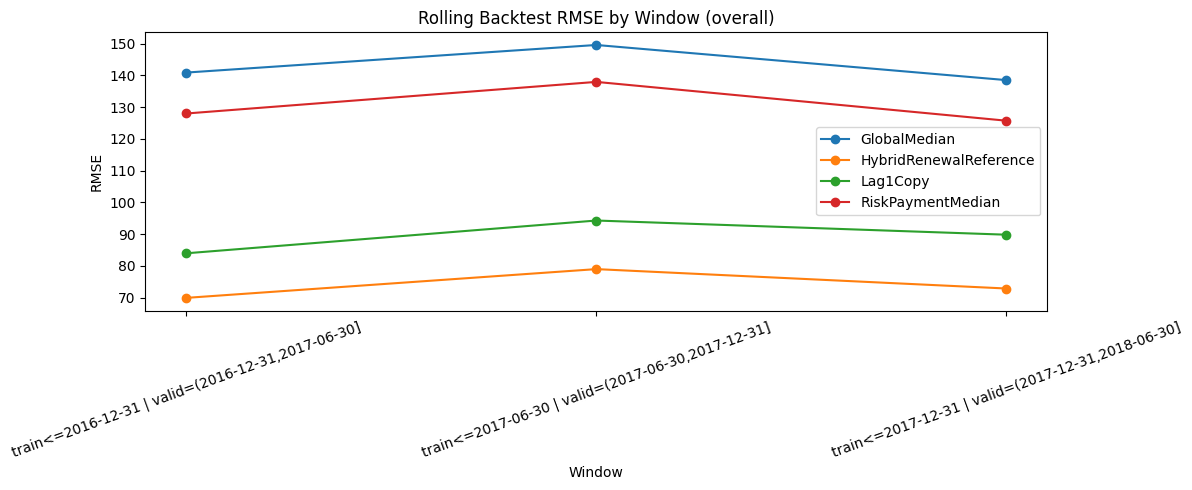

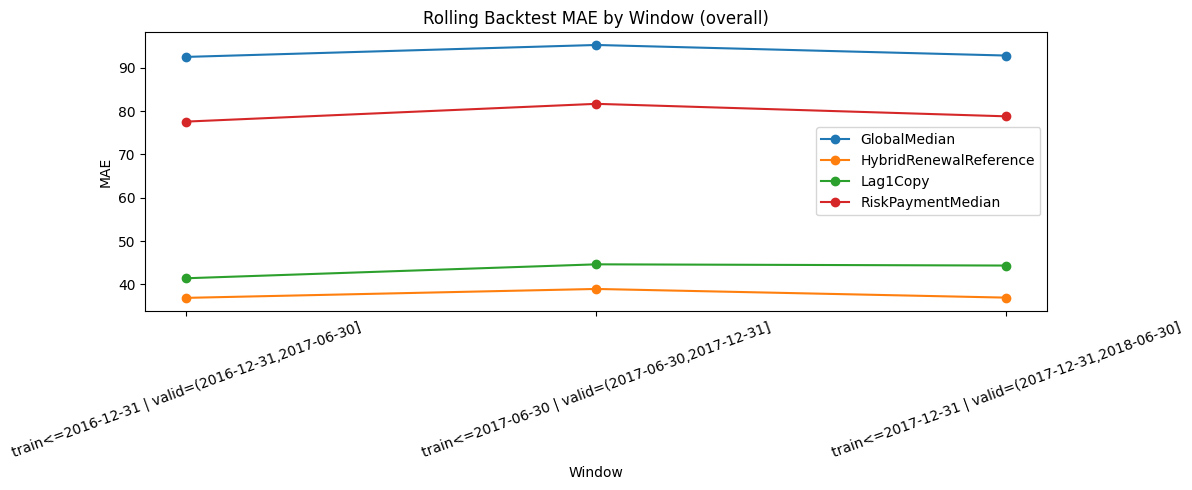

In [54]:

# BOX 8.5 — 真正完成 rolling backtest：3个时间窗 + 强baseline + 分群稳定性
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RUN_ROLLING_BACKTEST = True

# =========================
# 0) 安全评估函数
# =========================
def regression_metrics_safe(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce")
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce")

    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite_mask]
    y_pred = y_pred[finite_mask]

    if len(y_true) == 0:
        return {
            "n_used": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "MAPE_pct": np.nan,
        }

    nonzero_mask = y_true != 0
    mape = (
        np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        if nonzero_mask.any() else np.nan
    )

    return {
        "n_used": int(len(y_true)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
        "MAPE_pct": float(mape) if pd.notna(mape) else np.nan,
    }

def evaluate_by_group(df_eval, actual_col, pred_col, model_name, window_name, group_col="has_previous_policy_record"):
    rows = []

    overall = regression_metrics_safe(df_eval[actual_col], df_eval[pred_col])
    rows.append({
        "window": window_name,
        "model": model_name,
        "segment": "overall",
        "n_rows_raw": len(df_eval),
        **overall
    })

    for group_value, part in df_eval.groupby(group_col, dropna=False):
        met = regression_metrics_safe(part[actual_col], part[pred_col])
        rows.append({
            "window": window_name,
            "model": model_name,
            "segment": f"{group_col}={group_value}",
            "n_rows_raw": len(part),
            **met
        })

    return pd.DataFrame(rows)

# =========================
# 1) baseline 预测函数
# =========================
def make_baseline_maps(train_window):
    global_median_local = pd.to_numeric(train_window["premium"], errors="coerce").median()

    risk_payment_map_local = (
        train_window.groupby(["type_risk_label", "payment_label"], dropna=False)["premium"]
        .median()
    )

    risk_only_map_local = (
        train_window.groupby(["type_risk_label"], dropna=False)["premium"]
        .median()
    )

    return global_median_local, risk_payment_map_local, risk_only_map_local

def predict_risk_payment_median_local(df_part, global_median_local, risk_payment_map_local, risk_only_map_local):
    pair_index = list(zip(df_part["type_risk_label"], df_part["payment_label"]))
    risk_index = df_part["type_risk_label"]

    out = pd.Series(pair_index, index=df_part.index).map(risk_payment_map_local)
    risk_fallback = pd.Series(risk_index, index=df_part.index).map(risk_only_map_local)

    out = out.fillna(risk_fallback).fillna(global_median_local)
    return pd.to_numeric(out, errors="coerce")

# =========================
# 2) hybrid window 训练与预测
# =========================
def fit_hybrid_for_window(train_window, valid_window):
    train_window = train_window.copy()
    valid_window = valid_window.copy()

    renewal_train = train_window[
        (train_window["has_previous_policy_record"] == 1) &
        (train_window["premium_lag1"].notna())
    ].copy()

    renewal_valid = valid_window[
        (valid_window["has_previous_policy_record"] == 1) &
        (valid_window["premium_lag1"].notna())
    ].copy()

    cold_train = train_window[
        (train_window["has_previous_policy_record"] == 0) |
        (train_window["premium_lag1"].isna())
    ].copy()

    cold_valid = valid_window[
        (valid_window["has_previous_policy_record"] == 0) |
        (valid_window["premium_lag1"].isna())
    ].copy()

    # 只要任一条线路没有样本，这个 window 就跳过
    if len(renewal_train) == 0 or len(renewal_valid) == 0 or len(cold_train) == 0 or len(cold_valid) == 0:
        return None

    renewal_bundle_local = fit_lgbm_log_bundle(
        train_part=renewal_train,
        valid_part=renewal_valid,
        features=RENEWAL_FEATURES,
        target_mode="delta_log1p",
        model_tag="renewal_delta_local",
    )

    cold_bundle_local = fit_lgbm_log_bundle(
        train_part=cold_train,
        valid_part=cold_valid,
        features=COLD_START_FEATURES,
        target_mode="absolute_log1p",
        model_tag="cold_local",
    )

    renew_mask = (
        (valid_window["has_previous_policy_record"] == 1) &
        (valid_window["premium_lag1"].notna())
    )

    pred = pd.Series(index=valid_window.index, dtype=float)

    if renew_mask.any():
        pred.loc[renew_mask] = predict_from_bundle(
            renewal_bundle_local,
            valid_window.loc[renew_mask]
        )

    if (~renew_mask).any():
        pred.loc[~renew_mask] = predict_from_bundle(
            cold_bundle_local,
            valid_window.loc[~renew_mask]
        )

    return pred

# =========================
# 3) rolling windows
# =========================
# 这里保持和你原 notebook 一致：半年一个验证窗
backtest_windows = [
    ("2016-12-31", "2017-06-30"),
    ("2017-06-30", "2017-12-31"),
    ("2017-12-31", "2018-06-30"),
]

if RUN_ROLLING_BACKTEST:
    all_backtest_rows = []

    for train_end, valid_end in backtest_windows:
        window_name = f"train<={train_end} | valid=({train_end},{valid_end}]"
        print(f"\n===== Rolling Window: {window_name} =====")

        train_window, valid_window, _ = time_split(
            model_df,
            train_end=train_end,
            valid_end=valid_end
        )
        train_window = train_window.copy()
        valid_window = valid_window.copy()

        # 只评估 valid_window
        if len(train_window) == 0 or len(valid_window) == 0:
            print("跳过：train 或 valid 为空")
            continue

        # -------- baseline maps --------
        global_median_local, risk_payment_map_local, risk_only_map_local = make_baseline_maps(train_window)

        valid_window["pred_global_median"] = global_median_local
        valid_window["pred_risk_payment_median"] = predict_risk_payment_median_local(
            valid_window,
            global_median_local,
            risk_payment_map_local,
            risk_only_map_local
        )
        valid_window["pred_lag1_copy"] = pd.to_numeric(valid_window["premium_lag1"], errors="coerce").fillna(global_median_local)

        # -------- hybrid --------
        hybrid_pred = fit_hybrid_for_window(train_window, valid_window)

        if hybrid_pred is None:
            print("跳过：该时间窗 renewal/cold 某一路样本不足")
            continue

        valid_window["pred_hybrid"] = hybrid_pred

        # -------- collect metrics --------
        all_backtest_rows.append(
            evaluate_by_group(
                valid_window,
                actual_col="premium",
                pred_col="pred_hybrid",
                model_name="HybridRenewalReference",
                window_name=window_name,
                group_col="has_previous_policy_record"
            )
        )
        all_backtest_rows.append(
            evaluate_by_group(
                valid_window,
                actual_col="premium",
                pred_col="pred_lag1_copy",
                model_name="Lag1Copy",
                window_name=window_name,
                group_col="has_previous_policy_record"
            )
        )
        all_backtest_rows.append(
            evaluate_by_group(
                valid_window,
                actual_col="premium",
                pred_col="pred_global_median",
                model_name="GlobalMedian",
                window_name=window_name,
                group_col="has_previous_policy_record"
            )
        )
        all_backtest_rows.append(
            evaluate_by_group(
                valid_window,
                actual_col="premium",
                pred_col="pred_risk_payment_median",
                model_name="RiskPaymentMedian",
                window_name=window_name,
                group_col="has_previous_policy_record"
            )
        )

    rolling_backtest_detail_df = pd.concat(all_backtest_rows, axis=0, ignore_index=True)

    print("\n=== Rolling backtest 明细 ===")
    display(
        rolling_backtest_detail_df.style.format({
            "MAE": "{:.3f}",
            "RMSE": "{:.3f}",
            "R2": "{:.4f}",
            "MAPE_pct": "{:.2f}",
        })
    )

    # =========================
    # 4) summary：看稳定性
    # =========================
    rolling_backtest_summary_df = (
        rolling_backtest_detail_df
        .groupby(["model", "segment"], as_index=False)
        .agg(
            windows=("window", "nunique"),
            mean_MAE=("MAE", "mean"),
            std_MAE=("MAE", "std"),
            worst_MAE=("MAE", "max"),
            mean_RMSE=("RMSE", "mean"),
            std_RMSE=("RMSE", "std"),
            worst_RMSE=("RMSE", "max"),
            mean_R2=("R2", "mean"),
            std_R2=("R2", "std"),
            worst_R2=("R2", "min"),
            mean_MAPE_pct=("MAPE_pct", "mean"),
            std_MAPE_pct=("MAPE_pct", "std"),
        )
        .sort_values(["segment", "mean_RMSE", "mean_MAE"], ascending=[True, True, True])
        .reset_index(drop=True)
    )

    print("\n=== Rolling backtest 汇总（均值 / 波动 / 最差窗口）===")
    display(
        rolling_backtest_summary_df.style.format({
            "mean_MAE": "{:.3f}",
            "std_MAE": "{:.3f}",
            "worst_MAE": "{:.3f}",
            "mean_RMSE": "{:.3f}",
            "std_RMSE": "{:.3f}",
            "worst_RMSE": "{:.3f}",
            "mean_R2": "{:.4f}",
            "std_R2": "{:.4f}",
            "worst_R2": "{:.4f}",
            "mean_MAPE_pct": "{:.2f}",
            "std_MAPE_pct": "{:.2f}",
        })
    )

    # =========================
    # 5) 可视化：只看 overall 的 RMSE / MAE
    # =========================
    overall_plot_df = rolling_backtest_detail_df[
        rolling_backtest_detail_df["segment"] == "overall"
    ].copy()

    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(1, 1, 1)

    for model_name, part in overall_plot_df.groupby("model"):
        ax.plot(part["window"], part["RMSE"], marker="o", label=model_name)

    ax.set_title("Rolling Backtest RMSE by Window (overall)")
    ax.set_ylabel("RMSE")
    ax.set_xlabel("Window")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(1, 1, 1)

    for model_name, part in overall_plot_df.groupby("model"):
        ax.plot(part["window"], part["MAE"], marker="o", label=model_name)

    ax.set_title("Rolling Backtest MAE by Window (overall)")
    ax.set_ylabel("MAE")
    ax.set_xlabel("Window")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    print("RUN_ROLLING_BACKTEST = False，当前不会真正执行。")


SHAP bundle: global_absolute_lgbm_onehot
SHAP matrix shape: (700, 89)


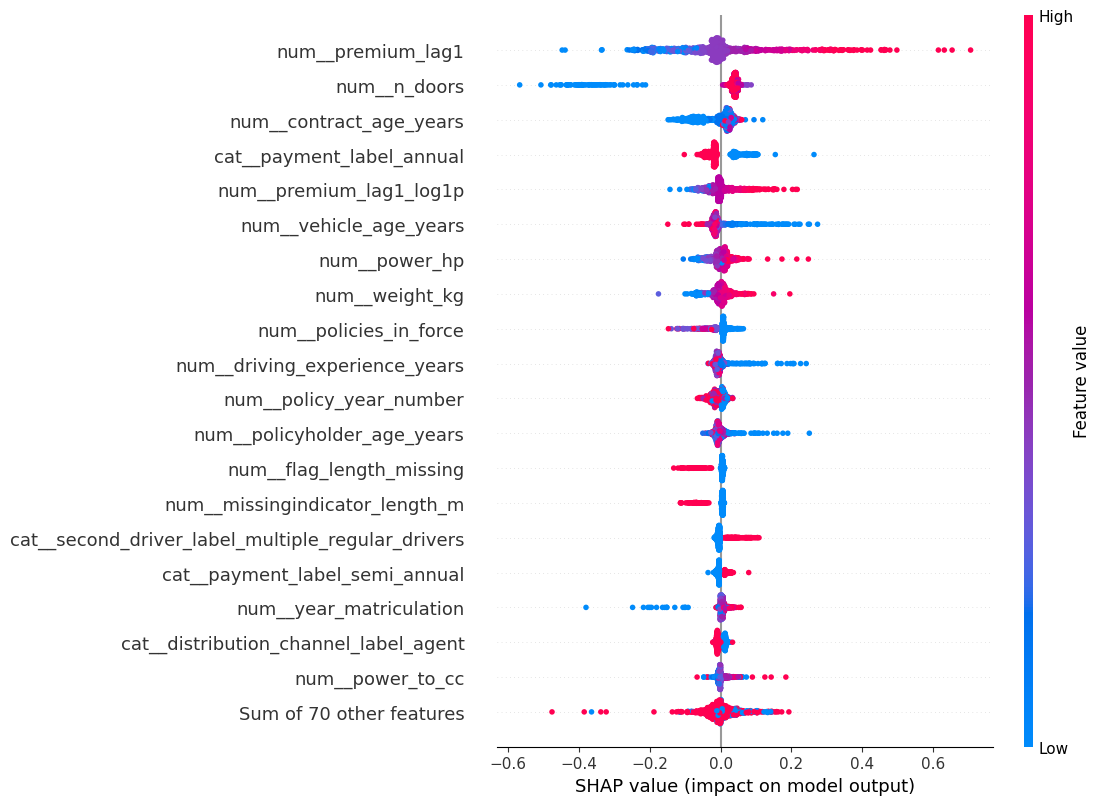

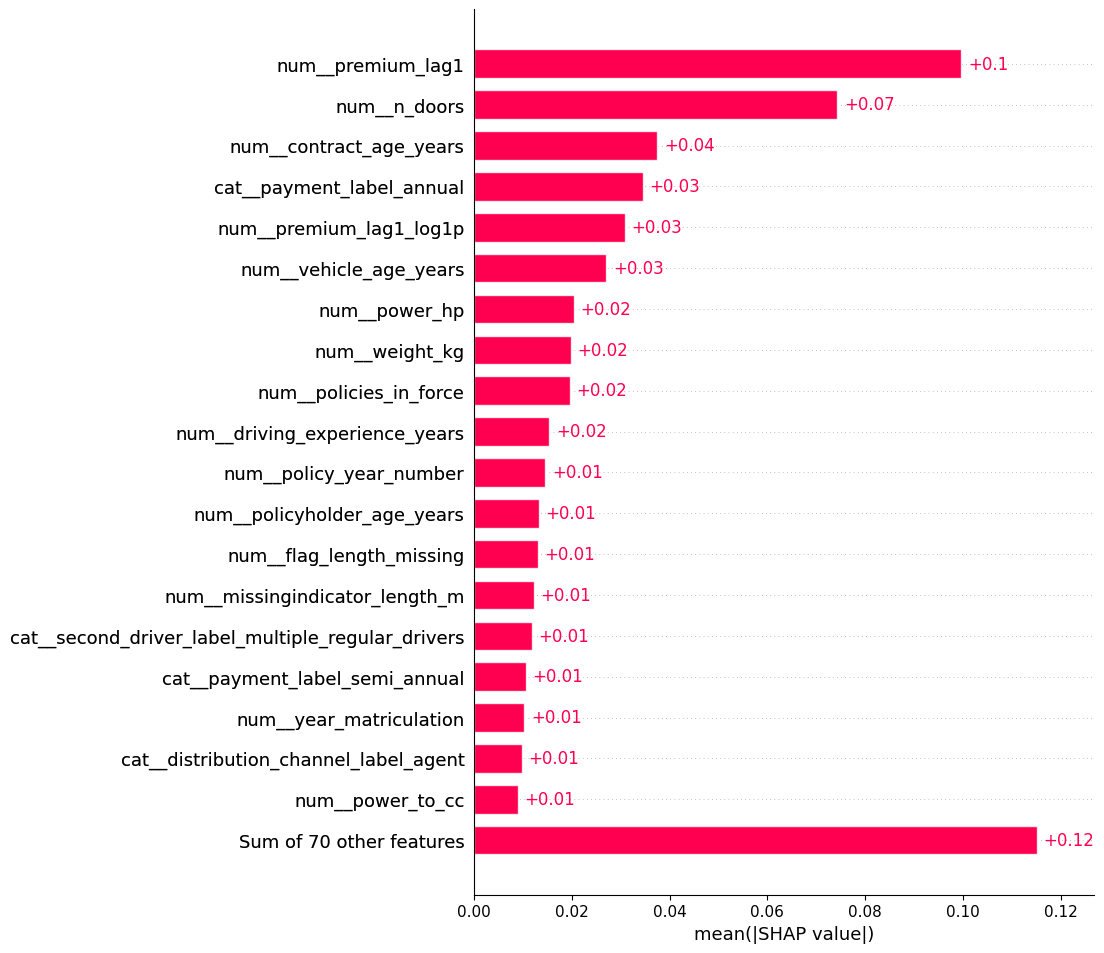

In [47]:

# BOX 8.6 — SHAP 终于别再用 Feature 50 这种无意义编号了
import shap

def make_dense_frame(x_matrix, feature_names):
    x_dense = x_matrix.toarray() if hasattr(x_matrix, "toarray") else np.asarray(x_matrix)
    return pd.DataFrame(x_dense, columns=feature_names)

def random_sample_df(df_part, n, random_state=RANDOM_STATE):
    n = min(n, len(df_part))
    return df_part.sample(n=n, random_state=random_state).copy()

def build_shap_explanation(bundle, sample_df, background_df):
    X_background = bundle["preprocessor"].transform(background_df[bundle["features"]])
    X_sample = bundle["preprocessor"].transform(sample_df[bundle["features"]])

    X_background_df = make_dense_frame(X_background, bundle["feature_names"])
    X_sample_df = make_dense_frame(X_sample, bundle["feature_names"])

    if bundle["model_family"] == "lightgbm":
        explainer = shap.TreeExplainer(bundle["model"])
        raw_shap = explainer(X_sample_df)
    else:
        explainer = shap.Explainer(bundle["model"], X_background_df)
        raw_shap = explainer(X_sample_df)

    shap_values = shap.Explanation(
        values=np.array(raw_shap.values),
        base_values=np.array(raw_shap.base_values),
        data=X_sample_df.values,
        feature_names=bundle["feature_names"],
    )

    return explainer, shap_values, X_sample_df

GLOBAL_SHAP_BUNDLE = pricing_reference_bundle["global_absolute"]

shap_valid_sample_raw = random_sample_df(valid_df, n=700, random_state=RANDOM_STATE)
shap_background_raw   = random_sample_df(train_df, n=300, random_state=RANDOM_STATE)

global_shap_explainer, global_shap_valid, global_shap_valid_df = build_shap_explanation(
    GLOBAL_SHAP_BUNDLE,
    sample_df=shap_valid_sample_raw,
    background_df=shap_background_raw,
)

print("SHAP bundle:", GLOBAL_SHAP_BUNDLE["tag"])
print("SHAP matrix shape:", global_shap_valid_df.shape)
shap.plots.beeswarm(global_shap_valid, max_display=20)
shap.plots.bar(global_shap_valid, max_display=20)


,customer_id,date_last_renewal,premium,premium_lag1,type_risk_label,payment_label,power_hp,vehicle_age_years,contract_age_years,has_previous_policy_record,pred_global_absolute_lgbm_onehot,absolute_error
103758,52454,2018-04-03,1327.51,1151.85,passenger_car,semi_annual,313,5,0.999316,1,1490.555251,163.045251


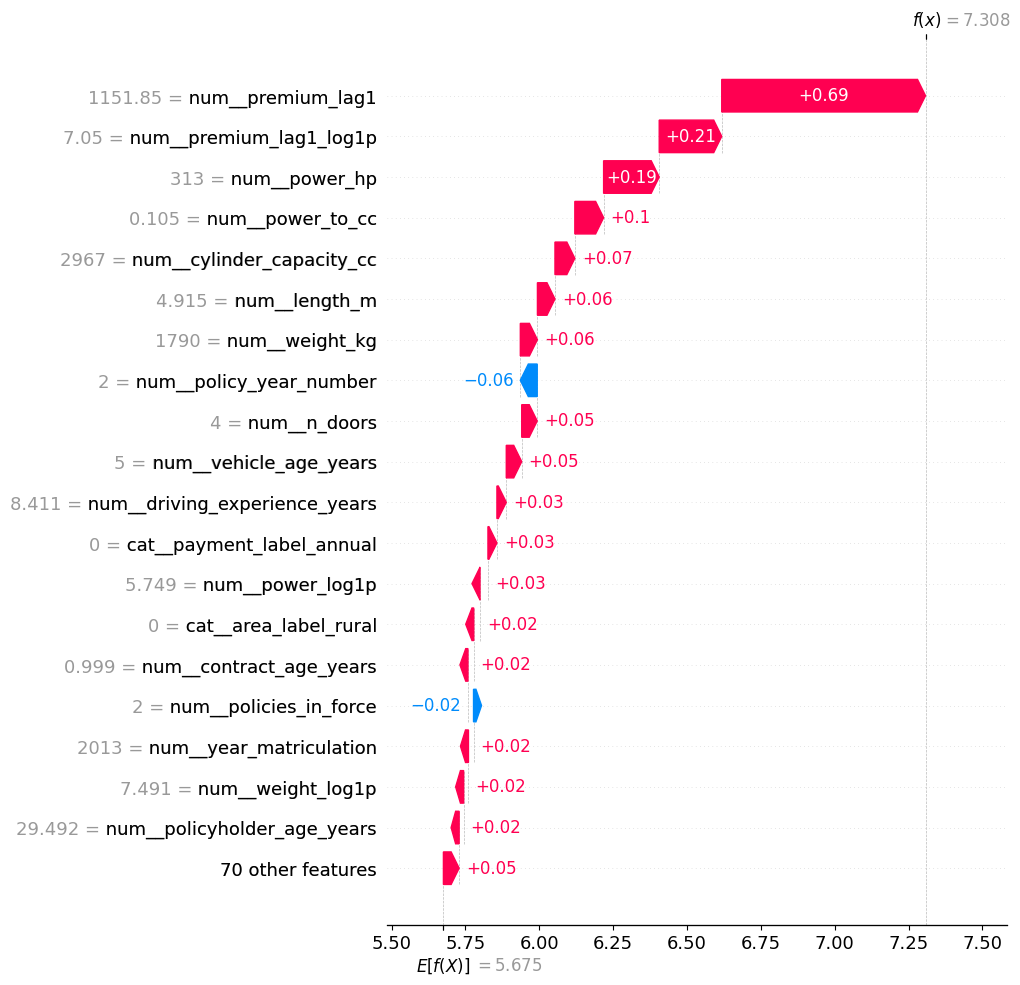

In [48]:

# BOX 8.7 — 单笔保单 waterfall：别只看全局图，去看“为什么这单被报高”
LOCAL_CASE_MODE = "highest_predicted"  # 可选: "highest_predicted", "largest_abs_error", "manual_index"
LOCAL_CASE_INDEX = None                # 如果上面选 manual_index，这里填 valid_df 的 index

valid_eval_hybrid["pred_global_absolute_lgbm_onehot"] = valid_eval_hybrid["pred_global_absolute_lgbm_onehot"].astype(float)

if LOCAL_CASE_MODE == "highest_predicted":
    local_idx = valid_eval_hybrid["pred_global_absolute_lgbm_onehot"].sort_values(ascending=False).index[0]
elif LOCAL_CASE_MODE == "largest_abs_error":
    local_idx = (valid_eval_hybrid["premium"] - valid_eval_hybrid["pred_global_absolute_lgbm_onehot"]).abs().sort_values(ascending=False).index[0]
elif LOCAL_CASE_MODE == "manual_index":
    if LOCAL_CASE_INDEX is None:
        raise ValueError("LOCAL_CASE_INDEX 不能为空")
    local_idx = LOCAL_CASE_INDEX
else:
    raise ValueError("unknown LOCAL_CASE_MODE")

local_case_raw = valid_df.loc[[local_idx]].copy()
local_case_meta = valid_eval_hybrid.loc[[local_idx], [
    "customer_id", "date_last_renewal", "premium", "premium_lag1",
    "type_risk_label", "payment_label", "power_hp", "vehicle_age_years",
    "contract_age_years", "has_previous_policy_record",
    "pred_global_absolute_lgbm_onehot",
]].copy()
local_case_meta["absolute_error"] = (local_case_meta["premium"] - local_case_meta["pred_global_absolute_lgbm_onehot"]).abs()

display(local_case_meta)

_, local_shap_value, local_x_df = build_shap_explanation(
    GLOBAL_SHAP_BUNDLE,
    sample_df=local_case_raw,
    background_df=shap_background_raw,
)

shap.plots.waterfall(local_shap_value[0], max_display=20)


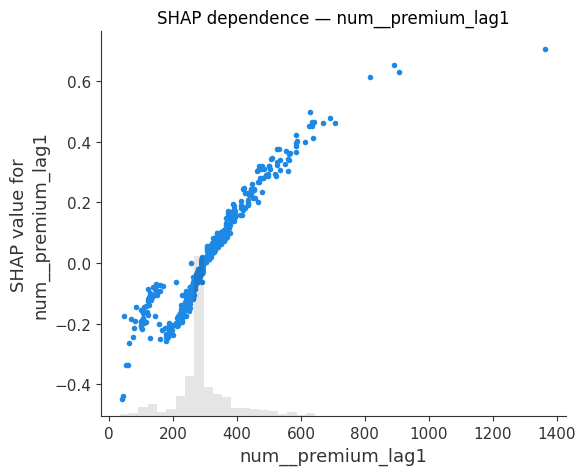

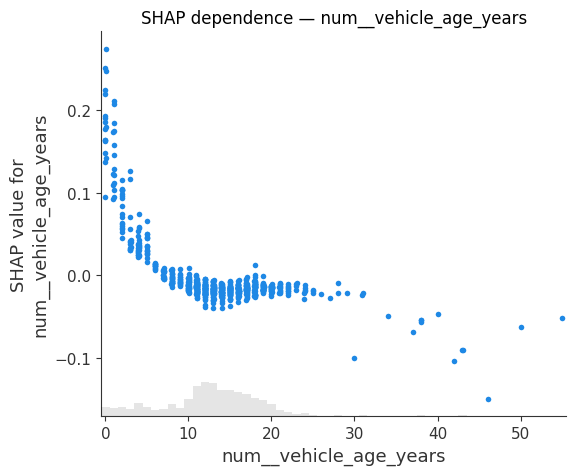

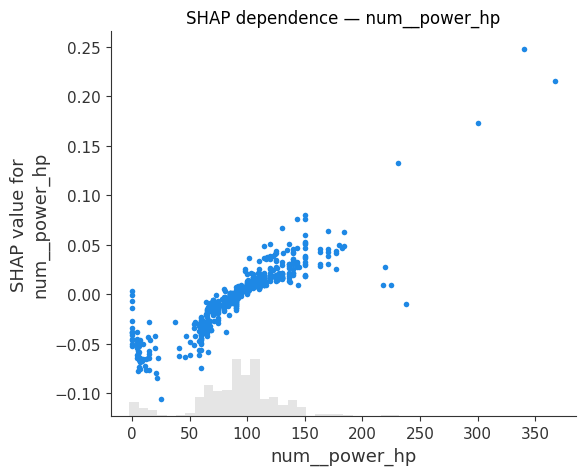

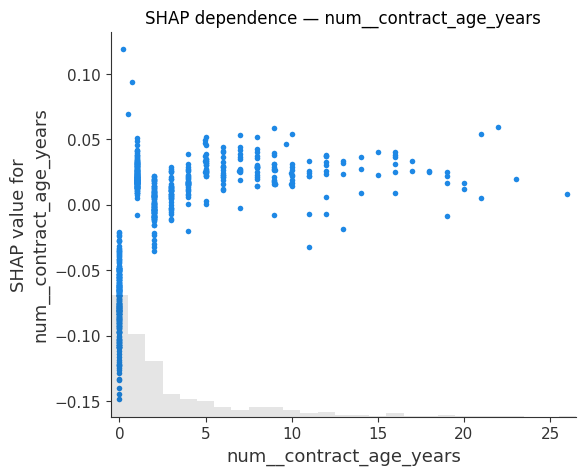

In [49]:

# BOX 8.8 — dependence plot：重点盯 premium_lag1、vehicle_age_years、power_hp、contract_age_years
DEPENDENCE_FEATURES = [
    "num__premium_lag1",
    "num__vehicle_age_years",
    "num__power_hp",
    "num__contract_age_years",
]

for feat in DEPENDENCE_FEATURES:
    if feat not in global_shap_valid_df.columns:
        print(f"跳过 {feat}：当前 bundle 的特征里没有它")
        continue
    shap.plots.scatter(global_shap_valid[:, feat], show=False)
    plt.title(f"SHAP dependence — {feat}")
    plt.show()


分组 SHAP 对比：如果 gap 很大，说明模型对有历史/无历史两群人的定价逻辑并不一致。


,feature,mean_abs_shap_all,mean_abs_shap_history_0,mean_abs_shap_history_1,gap_history1_minus_0
34,num__premium_lag1,0.099660,0.012850,0.139713,0.126862
14,num__contract_age_years,0.037485,0.074136,0.020575,-0.053561
35,num__premium_lag1_log1p,0.030871,0.004194,0.043180,0.038986
65,cat__payment_label_annual,0.034525,0.055316,0.024932,-0.030384
0,num__policies_in_force,0.019611,0.039779,0.010305,-0.029474
21,num__vehicle_age_years,0.027026,0.039883,0.021094,-0.018789
11,num__driving_experience_years,0.015365,0.025052,0.010896,-0.014156
6,num__weight_kg,0.019736,0.029239,0.015351,-0.013888
73,cat__second_driver_label_multiple_regular_drivers,0.011815,0.019357,0.008335,-0.011022
4,num__n_doors,0.074298,0.081166,0.071130,-0.010036


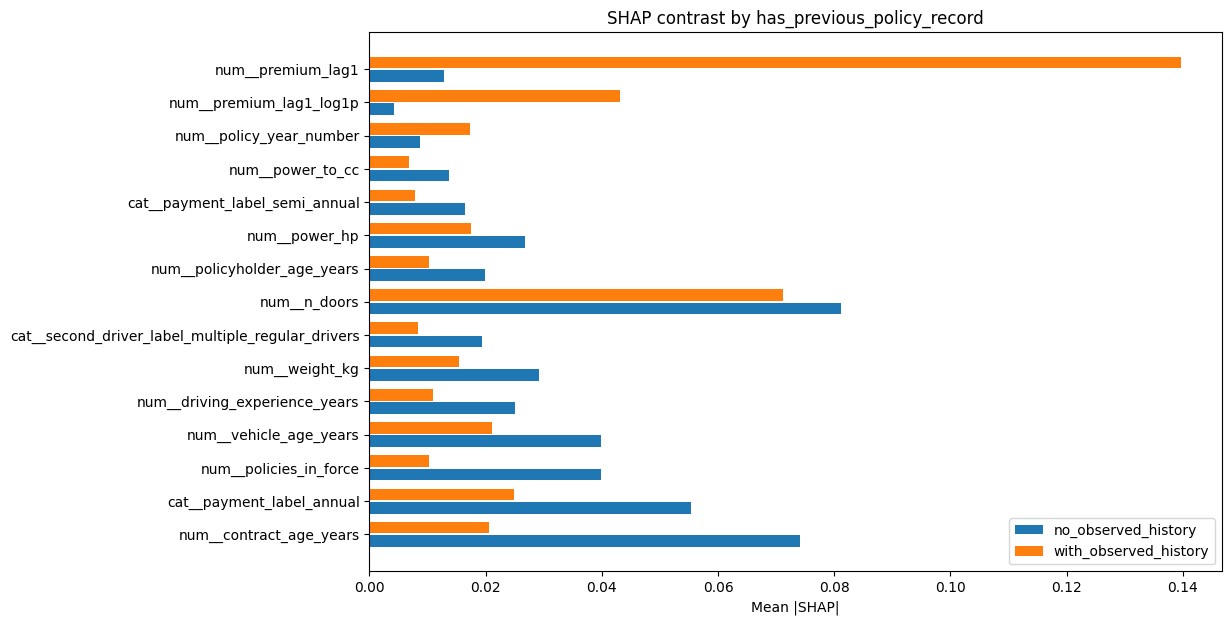

In [50]:

# BOX 8.9 — 按 has_previous_policy_record 分组：模型解释逻辑到底是不是一致
group_flag = shap_valid_sample_raw["has_previous_policy_record"].astype(int).values
mean_abs_all = np.abs(global_shap_valid.values).mean(axis=0)

group_compare_df = pd.DataFrame({
    "feature": GLOBAL_SHAP_BUNDLE["feature_names"],
    "mean_abs_shap_all": mean_abs_all,
})

for g in [0, 1]:
    mask = group_flag == g
    if mask.sum() == 0:
        group_compare_df[f"mean_abs_shap_history_{g}"] = np.nan
    else:
        group_compare_df[f"mean_abs_shap_history_{g}"] = np.abs(global_shap_valid.values[mask]).mean(axis=0)

group_compare_df["gap_history1_minus_0"] = (
    group_compare_df["mean_abs_shap_history_1"] - group_compare_df["mean_abs_shap_history_0"]
)
group_compare_df = group_compare_df.sort_values("gap_history1_minus_0", key=lambda s: s.abs(), ascending=False)

print("分组 SHAP 对比：如果 gap 很大，说明模型对有历史/无历史两群人的定价逻辑并不一致。")
display(group_compare_df.head(25))

plot_df = group_compare_df.head(15).sort_values("gap_history1_minus_0")
y_pos = np.arange(len(plot_df))

plt.figure(figsize=(11, 7))
plt.barh(y_pos - 0.2, plot_df["mean_abs_shap_history_0"], height=0.35, label="no_observed_history")
plt.barh(y_pos + 0.2, plot_df["mean_abs_shap_history_1"], height=0.35, label="with_observed_history")
plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("Mean |SHAP|")
plt.title("SHAP contrast by has_previous_policy_record")
plt.legend()
plt.show()


SHAP rank Spearman(valid vs test): 0.9983


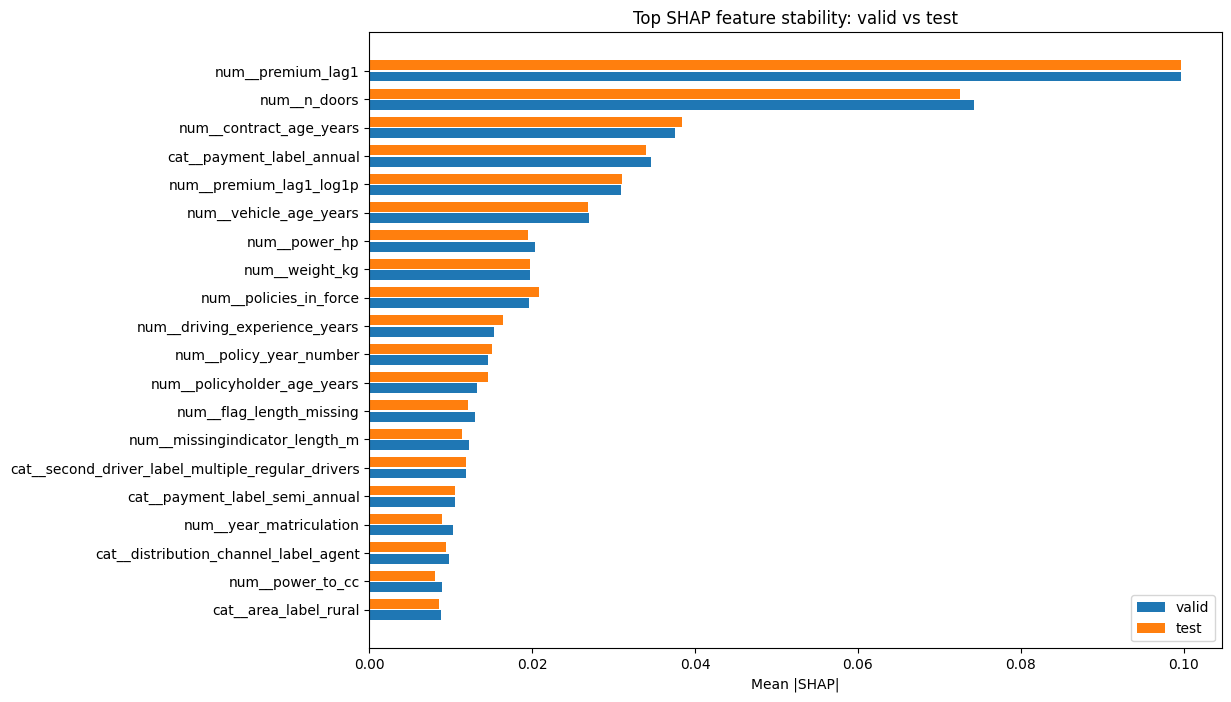

rank gap 最大的特征：


,valid_mean_abs,test_mean_abs,valid_rank,test_rank,rank_gap,mean_abs_gap
cat__type_fuel_label_diesel,0.000697,0.001130,56.0,50.0,6.0,4.333169e-04
cat__driver_age_band_<=25,0.000544,0.000725,61.0,55.0,6.0,1.811111e-04
cat__driver_age_band_36_45,0.000750,0.000651,54.0,58.0,4.0,9.881846e-05
num__past_total_claim_count,0.001244,0.001547,48.0,45.0,3.0,3.027051e-04
cat__driver_age_band_46_55,0.001040,0.000848,50.0,53.0,3.0,1.919712e-04
num__past_avg_claim_cost,0.000630,0.000512,58.0,61.0,3.0,1.181221e-04
num__cylinder_capacity_cc,0.008326,0.009009,21.0,18.0,3.0,6.832176e-04
num__policies_in_force,0.019611,0.020792,9.0,7.0,2.0,1.181578e-03
num__year_matriculation,0.010273,0.008951,17.0,19.0,2.0,1.321304e-03
num__power_to_cc,0.008951,0.008039,19.0,21.0,2.0,9.115928e-04


In [51]:

# BOX 8.10 — valid vs test 的 SHAP 稳定性：别只看一张图就自我感觉良好
shap_test_sample_raw = random_sample_df(test_df, n=700, random_state=RANDOM_STATE + 1)
_, global_shap_test, global_shap_test_df = build_shap_explanation(
    GLOBAL_SHAP_BUNDLE,
    sample_df=shap_test_sample_raw,
    background_df=shap_background_raw,
)

valid_mean_abs = pd.Series(np.abs(global_shap_valid.values).mean(axis=0), index=GLOBAL_SHAP_BUNDLE["feature_names"], name="valid_mean_abs")
test_mean_abs  = pd.Series(np.abs(global_shap_test.values).mean(axis=0),  index=GLOBAL_SHAP_BUNDLE["feature_names"], name="test_mean_abs")

shap_stability_df = pd.concat([valid_mean_abs, test_mean_abs], axis=1).fillna(0.0)
shap_stability_df["valid_rank"] = shap_stability_df["valid_mean_abs"].rank(ascending=False, method="min")
shap_stability_df["test_rank"]  = shap_stability_df["test_mean_abs"].rank(ascending=False, method="min")
shap_stability_df["rank_gap"]   = (shap_stability_df["valid_rank"] - shap_stability_df["test_rank"]).abs()
shap_stability_df["mean_abs_gap"] = (shap_stability_df["valid_mean_abs"] - shap_stability_df["test_mean_abs"]).abs()

rank_spearman = shap_stability_df[["valid_rank", "test_rank"]].corr(method="spearman").iloc[0, 1]
print("SHAP rank Spearman(valid vs test):", round(float(rank_spearman), 4))

top_stability = (
    shap_stability_df.sort_values(["valid_mean_abs", "test_mean_abs"], ascending=False)
    .head(20)
    .sort_values("valid_mean_abs")
)

plt.figure(figsize=(11, 8))
y_pos = np.arange(len(top_stability))
plt.barh(y_pos - 0.2, top_stability["valid_mean_abs"], height=0.35, label="valid")
plt.barh(y_pos + 0.2, top_stability["test_mean_abs"], height=0.35, label="test")
plt.yticks(y_pos, top_stability.index)
plt.xlabel("Mean |SHAP|")
plt.title("Top SHAP feature stability: valid vs test")
plt.legend()
plt.show()

print("rank gap 最大的特征：")
display(shap_stability_df.sort_values("rank_gap", ascending=False).head(20))


In [52]:

# BOX 8.11 — 报价引擎原型：现在才开始接近“能输出参考价”
def prettify_feature_name(feature_name):
    name = feature_name.replace("num__", "").replace("cat__", "")
    name = name.replace("missingindicator_", "missing_")
    name = name.replace("_", " ")
    return name

def collect_local_reason_codes(bundle, row_df, background_df, top_n=3):
    _, local_shap_value, local_x_df = build_shap_explanation(
        bundle=bundle,
        sample_df=row_df,
        background_df=background_df,
    )
    contrib = pd.Series(local_shap_value.values[0], index=bundle["feature_names"])
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index[:top_n])
    reason_codes = []
    for feat, val in top.items():
        direction = "上推价格" if val > 0 else "下拉价格"
        reason_codes.append(f"{prettify_feature_name(feat)} ({direction})")
    return reason_codes

# 用验证集来做 route 级别的区间校准；这里只是 prototype，不是最终生产方案
valid_route_scored = pricing_reference_bundle["global_valid_scored"].copy()
route_interval = {}
for route_name, part in valid_route_scored.groupby("route_used"):
    ratio = (part["premium"] / part["pred_hybrid_reference"]).replace([np.inf, -np.inf], np.nan).dropna()
    if len(ratio) == 0:
        route_interval[route_name] = {"low_mult": 0.85, "high_mult": 1.15}
        continue
    route_interval[route_name] = {
        "low_mult": float(np.quantile(ratio, 0.10)),
        "high_mult": float(np.quantile(ratio, 0.90)),
    }

pricing_reference_engine = {
    "global_absolute": global_absolute_bundle,
    "renewal_delta": renewal_delta_bundle,
    "cold_start": cold_start_bundle,
    "route_interval": route_interval,
    "required_columns": sorted(set(GLOBAL_FEATURES + ["premium_lag1", "has_previous_policy_record"])),
}

def score_reference_premium(input_df, engine, add_reason_codes=False):
    data = input_df.copy()

    missing_required = [c for c in engine["required_columns"] if c not in data.columns]
    if missing_required:
        raise ValueError(f"输入缺少必要字段: {missing_required}")

    renew_mask = (data["has_previous_policy_record"].fillna(0).astype(int) == 1) & (data["premium_lag1"].notna())

    pred = pd.Series(index=data.index, dtype=float)
    route_used = pd.Series(index=data.index, dtype="object")

    if renew_mask.any():
        pred.loc[renew_mask] = predict_from_bundle(engine["renewal_delta"], data.loc[renew_mask])
        route_used.loc[renew_mask] = "renewal_delta"

    cold_mask = ~renew_mask
    if cold_mask.any():
        pred.loc[cold_mask] = predict_from_bundle(engine["cold_start"], data.loc[cold_mask])
        route_used.loc[cold_mask] = "cold_start"

    out = pd.DataFrame(index=data.index)
    if "customer_id" in data.columns:
        out["customer_id"] = data["customer_id"]
    if "date_last_renewal" in data.columns:
        out["date_last_renewal"] = data["date_last_renewal"]

    out["route_used"] = route_used
    out["reference_premium"] = pred

    out["reference_premium_low"] = np.nan
    out["reference_premium_high"] = np.nan
    for route_name, limits in engine["route_interval"].items():
        mask = out["route_used"] == route_name
        out.loc[mask, "reference_premium_low"] = out.loc[mask, "reference_premium"] * limits["low_mult"]
        out.loc[mask, "reference_premium_high"] = out.loc[mask, "reference_premium"] * limits["high_mult"]

    out["relative_band_width_pct"] = (
        (out["reference_premium_high"] - out["reference_premium_low"]) / out["reference_premium"]
    ).replace([np.inf, -np.inf], np.nan) * 100

    manual_review_conditions = pd.Series(False, index=data.index)
    manual_review_reasons = pd.Series("", index=data.index, dtype="object")

    critical_missing = data[["power_hp", "vehicle_age_years", "contract_age_years", "type_risk_label"]].isna().any(axis=1)
    manual_review_conditions = manual_review_conditions | critical_missing
    manual_review_reasons = manual_review_reasons.mask(critical_missing, manual_review_reasons + "|critical_missing_fields")

    unknown_type_fuel = data["type_fuel_label"].astype(str).eq("unknown")
    manual_review_conditions = manual_review_conditions | unknown_type_fuel
    manual_review_reasons = manual_review_reasons.mask(unknown_type_fuel, manual_review_reasons + "|unknown_fuel")

    cold_route = out["route_used"].eq("cold_start")
    manual_review_conditions = manual_review_conditions | cold_route
    manual_review_reasons = manual_review_reasons.mask(cold_route, manual_review_reasons + "|cold_start_route")

    wide_band = out["relative_band_width_pct"] > 60
    manual_review_conditions = manual_review_conditions | wide_band
    manual_review_reasons = manual_review_reasons.mask(wide_band, manual_review_reasons + "|wide_uncertainty_band")

    out["manual_review_flag"] = manual_review_conditions.astype(int)
    out["manual_review_reason"] = manual_review_reasons.str.lstrip("|").replace("", "none")

    if add_reason_codes:
        reason_1, reason_2, reason_3 = [], [], []
        for idx in data.index:
            row_df = data.loc[[idx]].copy()
            route = out.loc[idx, "route_used"]
            bundle = engine["renewal_delta"] if route == "renewal_delta" else engine["cold_start"]
            reasons = collect_local_reason_codes(bundle, row_df=row_df, background_df=shap_background_raw, top_n=3)
            reasons = reasons + ["", "", ""]
            reason_1.append(reasons[0])
            reason_2.append(reasons[1])
            reason_3.append(reasons[2])

        out["reason_code_1"] = reason_1
        out["reason_code_2"] = reason_2
        out["reason_code_3"] = reason_3

    return out

# demo：先拿测试集前 10 行做个报价原型演示
quote_demo_input = test_df.head(10).copy()
quote_demo_output = score_reference_premium(
    input_df=quote_demo_input,
    engine=pricing_reference_engine,
    add_reason_codes=True,
)

display(quote_demo_output)

# 最小可持久化 artifact
pricing_engine_artifact = {
    "route_interval": pricing_reference_engine["route_interval"],
    "required_columns": pricing_reference_engine["required_columns"],
    "global_absolute": {
        "tag": global_absolute_bundle["tag"],
        "features": global_absolute_bundle["features"],
        "feature_names": global_absolute_bundle["feature_names"],
        "prediction_space": global_absolute_bundle["prediction_space"],
        "preprocessor": global_absolute_bundle["preprocessor"],
        "model": global_absolute_bundle["model"],
    },
    "renewal_delta": {
        "tag": renewal_delta_bundle["tag"],
        "features": renewal_delta_bundle["features"],
        "feature_names": renewal_delta_bundle["feature_names"],
        "prediction_space": renewal_delta_bundle["prediction_space"],
        "lag_col": renewal_delta_bundle["lag_col"],
        "delta_clip_low": renewal_delta_bundle["delta_clip_low"],
        "delta_clip_high": renewal_delta_bundle["delta_clip_high"],
        "preprocessor": renewal_delta_bundle["preprocessor"],
        "model": renewal_delta_bundle["model"],
    },
    "cold_start": {
        "tag": cold_start_bundle["tag"],
        "features": cold_start_bundle["features"],
        "feature_names": cold_start_bundle["feature_names"],
        "prediction_space": cold_start_bundle["prediction_space"],
        "preprocessor": cold_start_bundle["preprocessor"],
        "model": cold_start_bundle["model"],
    },
}

artifact_dir = locate_file(["feature_manifest.json"]).parent
artifact_path = artifact_dir / "pricing_reference_engine_artifact.joblib"
joblib.dump(pricing_engine_artifact, artifact_path)
print("artifact saved to:", artifact_path)


,customer_id,date_last_renewal,route_used,reference_premium,reference_premium_low,reference_premium_high,relative_band_width_pct,manual_review_flag,manual_review_reason,reason_code_1,reason_code_2,reason_code_3
3,1,2018-11-05,renewal_delta,211.802071,194.918257,222.648945,13.092737,0,none,premium lag1 (上推价格),loss ratio prev year (下拉价格),type risk label passenger car (下拉价格)
5,2,2018-09-26,renewal_delta,219.421033,201.929873,230.658091,13.092737,0,none,contract age years (上推价格),payment label annual (上推价格),loss ratio prev year (下拉价格)
9,3,2018-11-29,renewal_delta,377.432512,347.345457,396.761703,13.092737,0,none,premium lag1 (下拉价格),contract age years (下拉价格),loss ratio prev year (下拉价格)
12,4,2018-10-21,renewal_delta,116.075956,106.822955,122.020474,13.092737,0,none,premium lag1 (上推价格),premium lag1 log1p (上推价格),contract age years (下拉价格)
36,14,2018-09-25,renewal_delta,438.873930,403.889070,461.349678,13.092737,0,none,premium lag1 (下拉价格),contract age years (下拉价格),loss ratio prev year (下拉价格)
39,15,2018-07-24,renewal_delta,312.462718,287.554734,328.464656,13.092737,0,none,premium lag1 (下拉价格),contract age years (下拉价格),loss ratio prev year (下拉价格)
45,17,2018-08-15,renewal_delta,381.762134,351.329944,401.313056,13.092737,0,none,premium lag1 (下拉价格),contract age years (下拉价格),loss ratio prev year (下拉价格)
51,20,2018-10-20,renewal_delta,352.058941,323.994543,370.088693,13.092737,0,none,premium lag1 (下拉价格),contract age years (上推价格),loss ratio prev year (下拉价格)
69,29,2018-09-28,renewal_delta,339.247853,312.204691,356.621520,13.092737,0,none,premium lag1 (下拉价格),contract age years (上推价格),loss ratio prev year (下拉价格)
89,39,2018-10-15,renewal_delta,410.077275,377.387942,431.078280,13.092737,0,none,loss ratio prev year (上推价格),past total claim count (上推价格),past total claim cost (上推价格)


artifact saved to: /content/drive/MyDrive/car_insurance_project_outputs/pricing_reference_engine_artifact.joblib


valid interval coverage: 80.00%
valid manual review rate: 33.96%
test interval coverage: 79.67%
test manual review rate: 31.91%
valid top 10% premium underpricing rate: 75.32%
test top 10% premium underpricing rate: 81.59%


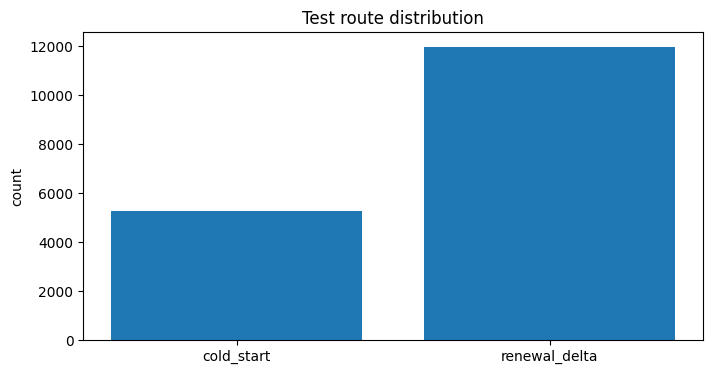

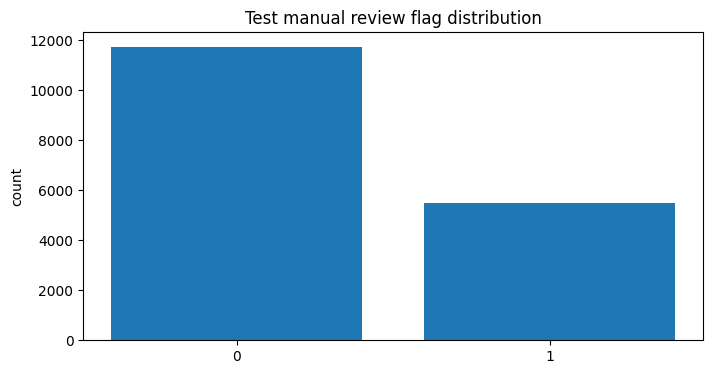

In [53]:

# BOX 8.12 — 报价引擎原型的最后一击：别只看点预测，检查它在哪些地方危险
engine_valid_output = score_reference_premium(valid_df.copy(), pricing_reference_engine, add_reason_codes=False)
engine_test_output  = score_reference_premium(test_df.copy(), pricing_reference_engine, add_reason_codes=False)

engine_valid_scored = valid_df[["premium", "has_previous_policy_record", "type_risk_label"]].copy()
engine_valid_scored = pd.concat([engine_valid_scored, engine_valid_output[[
    "route_used", "reference_premium", "reference_premium_low", "reference_premium_high",
    "relative_band_width_pct", "manual_review_flag"
]]], axis=1)

engine_test_scored = test_df[["premium", "has_previous_policy_record", "type_risk_label"]].copy()
engine_test_scored = pd.concat([engine_test_scored, engine_test_output[[
    "route_used", "reference_premium", "reference_premium_low", "reference_premium_high",
    "relative_band_width_pct", "manual_review_flag"
]]], axis=1)

for split_name, scored in [("valid", engine_valid_scored), ("test", engine_test_scored)]:
    covered = ((scored["premium"] >= scored["reference_premium_low"]) & (scored["premium"] <= scored["reference_premium_high"])).mean()
    review_rate = scored["manual_review_flag"].mean()
    print(f"{split_name} interval coverage: {covered:.2%}")
    print(f"{split_name} manual review rate: {review_rate:.2%}")

# 高价尾部是否仍然被低估
for split_name, scored in [("valid", engine_valid_scored), ("test", engine_test_scored)]:
    threshold = scored["premium"].quantile(0.90)
    high_part = scored[scored["premium"] >= threshold].copy()
    underpricing_rate = (high_part["reference_premium"] < high_part["premium"]).mean()
    print(f"{split_name} top 10% premium underpricing rate: {underpricing_rate:.2%}")

# 画 route 分布和人工复核分布
route_counts = engine_test_scored["route_used"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(route_counts.index.astype(str), route_counts.values)
plt.title("Test route distribution")
plt.ylabel("count")
plt.show()

review_counts = engine_test_scored["manual_review_flag"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(review_counts.index.astype(str), review_counts.values)
plt.title("Test manual review flag distribution")
plt.ylabel("count")
plt.show()
